[DEBUG] Vaccine columns: ['Cumulative_Doses', 'Influenza_Season', 'Setting', 'Week_ID', 'Current_Season_Week_Ending_Label', 'MMWR_Week_Order', 'MMWR_Year', 'MMWR_Week', 'MMWR_Day', 'Dose', 'Current_Through', 'Location_and_Flu_Season_Order', 'Age_Group']
Episode 1: Total Reward = 235.86
Episode 2: Total Reward = 233.21
Episode 3: Total Reward = 232.43
Episode 4: Total Reward = 241.09
Episode 5: Total Reward = 237.27
Episode 6: Total Reward = 222.30
Episode 7: Total Reward = 245.64
Episode 8: Total Reward = 231.71
Episode 9: Total Reward = 239.46
Episode 10: Total Reward = 243.10
Episode 11: Total Reward = 232.39
Episode 12: Total Reward = 240.93
Episode 13: Total Reward = 223.56
Episode 14: Total Reward = 240.00
Episode 15: Total Reward = 228.95
Episode 16: Total Reward = 231.59
Episode 17: Total Reward = 226.90
Episode 18: Total Reward = 239.17
Episode 19: Total Reward = 243.26
Episode 20: Total Reward = 250.28
Episode 21: Total Reward = 232.01
Episode 22: Total Reward = 234.48
Episode

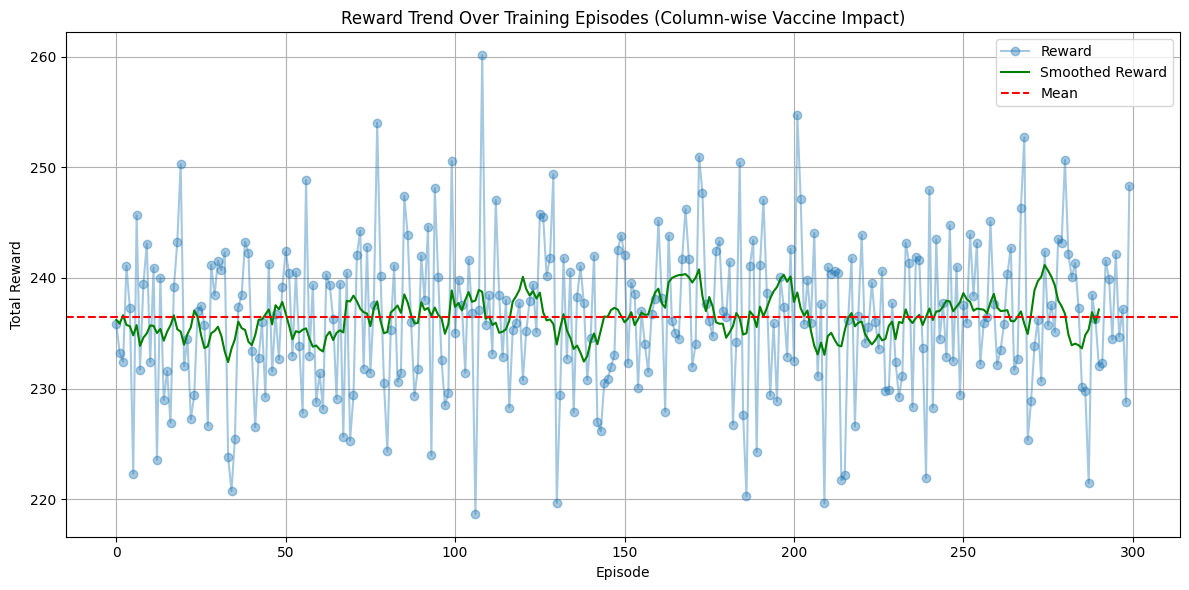

In [8]:
import gym
from gym import spaces
import numpy as np
import pandas as pd
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import sys

# ----------------------
# Helper
# ----------------------
def normalize(series):
    return (series - series.min()) / (series.max() + 1e-8)

def load_data(disease_type="COVID", level="normalized"):
    if disease_type != "COVID":
        print("❌ Only COVID is supported for vaccination integration.")
        return None

    # File paths
    hosp_path = "C:\\Users\\Lenovo\\MultiVacSim\\data\\covid\\weekly_covid_hospitilization.csv"
    death_path = "C:\\Users\\Lenovo\\MultiVacSim\\data\\covid\\Total_Covid_death_by_age.csv"
    vaccine_path = "C:\\Users\\Lenovo\\MultiVacSim\\data\\covid\\Main_Vaccination.csv"

    missing = [p for p in [hosp_path, death_path, vaccine_path] if not os.path.exists(p)]
    if missing:
        print("❌ Missing files:")
        for f in missing:
            print(f" - {f}")
        return None

    try:
        hosp = pd.read_csv(hosp_path)
        deaths = pd.read_csv(death_path)
        vaccine = pd.read_csv(vaccine_path)

        print("[DEBUG] Vaccine columns:", vaccine.columns.tolist())

        # Numeric vaccine features (column-wise)
        total_doses = vaccine["Cumulative_Doses"].dropna().astype(float).sum()
        mean_dose = vaccine["Dose"].dropna().astype(float).mean() if "Dose" in vaccine.columns else 0
        total_population = 330_000_000
        vaccine_supply_ratio = total_doses / total_population
        dose_rate = mean_dose / 100_000  # scale dose

        hosp_col = hosp.columns[-1]
        death_col = deaths.columns[-1]
        hosp[hosp_col] = pd.to_numeric(hosp[hosp_col], errors='coerce')
        deaths[death_col] = pd.to_numeric(deaths[death_col], errors='coerce')
        hosp = hosp.dropna(subset=[hosp_col])
        deaths = deaths.dropna(subset=[death_col])

        # Create 1-row dataframe with column-wise features
        df = pd.DataFrame([{
            "hospitalization_rate": normalize(hosp[hosp_col]).mean() if level == "normalized" else hosp[hosp_col].mean() / 100,
            "death_rate": normalize(deaths[death_col]).mean() if level == "normalized" else deaths[death_col].mean() / 100,
            "vaccine_supply_ratio": vaccine_supply_ratio,
            "mean_weekly_dose": dose_rate
        }])
        return df
    except Exception as e:
        print(f"[ERROR loading data]: {e}")
        return None

# ----------------------
# Env (uses same 1 state each reset, with column stats)
# ----------------------
class VaccineEnv(gym.Env):
    def __init__(self, disease_type="COVID", max_steps=100, data_df=None):
        super(VaccineEnv, self).__init__()
        self.disease_type = disease_type
        self.max_steps = max_steps
        self.real_data = data_df

        self.state_size = 6  # [hosp, death, coverage, wastage, vaccine_ratio, dose_rate]
        self.observation_space = spaces.Box(low=0, high=1, shape=(self.state_size,), dtype=np.float32)
        self.action_space = spaces.Discrete(6)
        self.state = None
        self.current_step = 0

    def _get_initial_state(self):
        state = np.zeros(self.state_size)
        if self.real_data is not None:
            row = self.real_data.iloc[0]
            state[0] = row.get("hospitalization_rate", 0.1)
            state[1] = row.get("death_rate", 0.01)
            state[2] = 0.2  # coverage
            state[3] = 0.1  # wastage
            state[4] = row.get("vaccine_supply_ratio", 0.5)
            state[5] = row.get("mean_weekly_dose", 0.01)
        else:
            print("⚠️ Using synthetic state.")
            state = self.observation_space.sample()
        return np.clip(state, 0, 1).astype(np.float32)

    def step(self, action):
        next_state = self.state.copy()
        coverage_idx, wastage_idx, vax_idx = 2, 3, 4

        next_state[coverage_idx] += random.uniform(0.01, 0.03) * (1 - next_state[coverage_idx])
        next_state[wastage_idx] += random.uniform(0.0, 0.01)

        # Vaccination impact
        reduction = next_state[vax_idx] * 0.1
        next_state[0] = max(0, next_state[0] - reduction)  # hosp
        next_state[1] = max(0, next_state[1] - reduction * 0.5)  # death

        self.state = np.clip(next_state, 0, 1).astype(np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        reward = self.calculate_reward(self.state)

        return self.state, reward, done, {}

    def calculate_reward(self, state):
        hosp, death, coverage, waste = state[0], state[1], state[2], state[3]
        return -10 * hosp - 15 * death + 12 * coverage - 5 * waste

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = self._get_initial_state()
        self.current_step = 0
        return self.state

# ----------------------
# DQN
# ----------------------
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# ----------------------
# Train
# ----------------------
if __name__ == "__main__":
    disease = "COVID"
    level = "normalized"

    data = load_data(disease, level)
    if data is None or data.empty:
        print("❌ Failed to load data. Exiting.")
        sys.exit()

    env = VaccineEnv(disease_type=disease, max_steps=50, data_df=data)
    state_dim = env.state_size
    action_dim = env.action_space.n
    q_network = DQN(state_dim, action_dim)
    optimizer = optim.Adam(q_network.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    num_episodes = 300
    gamma = 0.95
    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.995

    reward_history = []

    for episode in range(num_episodes):
        state = env.reset()
        state = torch.tensor(state, dtype=torch.float32)
        total_reward = 0

        for _ in range(50):
            action = random.choice(range(action_dim)) if random.random() < epsilon else torch.argmax(q_network(state)).item()
            next_state, reward, done, _ = env.step(action)
            next_state = torch.tensor(next_state, dtype=torch.float32)
            target = reward + gamma * torch.max(q_network(next_state))
            prediction = q_network(state)[action]
            loss = loss_fn(prediction, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            state = next_state
            total_reward += reward
            if done:
                break

        reward_history.append(total_reward)
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        print(f"Episode {episode + 1}: Total Reward = {total_reward:.2f}")

    # Plot
    def moving_avg(x, w=10): return np.convolve(x, np.ones(w)/w, mode='valid')
    plt.figure(figsize=(12, 6))
    plt.plot(reward_history, 'o-', alpha=0.4, label='Reward')
    if len(reward_history) >= 10:
        plt.plot(moving_avg(reward_history), label='Smoothed Reward', color='green')
    plt.axhline(np.mean(reward_history), color='red', linestyle='--', label='Mean')
    plt.title("Reward Trend Over Training Episodes (Column-wise Vaccine Impact)")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Reinforcement Learning Simulation: Vaccine Strategy Environment:

This cell sets up and runs a custom OpenAI Gym environment (VaccineEnv) designed to simulate decision-making for public health vaccine strategies—either for COVID-19 or Influenza (Flu).

🧠 Environment Design: VaccineEnv
Based on disease type (COVID or FLU), different input features are used to define the agent’s environment state.

The state includes metrics such as:

Hospitalization rate

Death rate

Vaccination coverage

Wastage

Variant severity (COVID only)

Booster demand (COVID only)

Seasonality factor (Flu only)

State normalization is applied for stable training and evaluation.

Actions: The agent can choose from 6 discrete actions, which might represent different intervention or vaccination strategies.

Rewards: A simple reward function encourages higher overall health metrics, while lightly penalizing aggressive actions.

🔄 What the Simulation Does:
Loads preprocessed COVID and Flu datasets.

Initializes an environment for Flu (COVID version included but commented out).

Runs the environment for 20 time steps using random actions.

Outputs action-reward pairs at each step and prints the total reward at the end.

This provides a scaffold for training more intelligent agents in the future using reinforcement learning.

In [10]:
import gym
from gym import spaces
import numpy as np
import pandas as pd

# Load processed data
flu_data_path = "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\"
covid_data_path = "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\"

# Load datasets
flu_dfs = {
    "vaccination": pd.read_csv(flu_data_path + "flu_vaccination_data_s.csv"),
    "hospitalization": pd.read_csv(flu_data_path + "flu_hospitalization_data_s.csv"),
    "mortality": pd.read_csv(flu_data_path + "flu_mortality_data_s.csv"),
    "trend": pd.read_csv(flu_data_path + "flu_trend_data_s.csv"),
}
covid_dfs = {
    "vaccination": pd.read_csv(covid_data_path + "covid_vaccination_data_s.csv"),
    "hospitalization": pd.read_csv(covid_data_path + "covid_hospitalization_data_s.csv"),
    "mortality": pd.read_csv(covid_data_path + "covid_mortality_data_s.csv"),
    "trend": pd.read_csv(covid_data_path + "covid_trend_data_s.csv"),
}

class VaccineEnv(gym.Env):
    def __init__(self, disease_type="COVID", data_dict=None):
        super(VaccineEnv, self).__init__()
        self.disease_type = disease_type
        self.data_dict = data_dict
        self.pointer = 0  # Time step pointer

        if disease_type == "COVID":
            self.state_columns = [
                "hospitalization_rate", "death_rate",
                "vaccination_coverage", "vaccine_wastage",
                "variant_severity", "booster_demand",
            ]
        else:
            self.state_columns = [
                "flu_hospitalization_rate", "flu_death_rate",
                "flu_vaccination_coverage", "flu_wastage",
                "flu_seasonality_factor"
            ]

        self.state_size = len(self.state_columns)
        self.observation_space = spaces.Box(low=0, high=1, shape=(self.state_size,), dtype=np.float32)
        self.action_space = spaces.Discrete(6)

        # Preprocess the data to extract state values (normalize for RL)
        self.state_data = self.prepare_state_data()

    def prepare_state_data(self):
        df = pd.DataFrame()
        if self.disease_type == "COVID":
            df["hospitalization_rate"] = self.data_dict["hospitalization"]["hospitalization_rate"].fillna(0)
            df["death_rate"] = self.data_dict["mortality"]["death_rate"].fillna(0)
            df["vaccination_coverage"] = self.data_dict["vaccination"]["vaccination_coverage"].fillna(0)
            df["vaccine_wastage"] = np.random.rand(len(df)) * 0.1  # Placeholder
            df["variant_severity"] = np.random.rand(len(df)) * 0.2
            df["booster_demand"] = np.random.rand(len(df)) * 0.3
        else:
            df["flu_hospitalization_rate"] = self.data_dict["hospitalization"]["flu_hospitalization_rate"].fillna(0)
            df["flu_death_rate"] = self.data_dict["mortality"]["flu_death_rate"].fillna(0)
            df["flu_vaccination_coverage"] = self.data_dict["vaccination"]["vaccination_coverage"].fillna(0)
            df["flu_wastage"] = np.random.rand(len(df)) * 0.1
            df["flu_seasonality_factor"] = np.random.rand(len(df)) * 0.4

        # Normalize
        return (df - df.min()) / (df.max() - df.min() + 1e-6)

    def get_state(self):
        if self.pointer >= len(self.state_data):
            self.pointer = 0  # Reset if at the end
        state = self.state_data.iloc[self.pointer].values.astype(np.float32)
        return state

    def step(self, action):
        state = self.get_state()
        reward = self.calculate_reward(state, action)
        self.pointer += 1
        done = self.pointer >= len(self.state_data)
        return state, reward, done, {}

    def calculate_reward(self, state, action):
        # Basic linear reward
        return np.sum(state) - action  # reward decreases slightly with more aggressive actions

    def reset(self):
        self.pointer = 0
        return self.get_state()

# Initialize environments
# covid_env = VaccineEnv("COVID", covid_dfs)
flu_env = VaccineEnv("FLU", flu_dfs)

# Simulate each environment over 20 timesteps
def simulate(env, disease_name):
    print(f"\n🎮 Simulating {disease_name} Vaccine Environment...")
    state = env.reset()
    total_reward = 0
    for t in range(20):
        action = env.action_space.sample()
        next_state, reward, done, _ = env.step(action)
        total_reward += reward
        print(f"Timestep {t+1}: Action={action}, Reward={reward:.2f}")
        if done:
            break
    print(f"✅ Total Reward for {disease_name}: {total_reward:.2f}")

# simulate(covid_env, "COVID-19")
simulate(flu_env, "Flu")


C:\Users\naing\AppData\Local\Temp\ipykernel_26592\1827809831.py:13: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,14,15,17,20,22,25,26,30,33,39,45) have mixed types. Specify dtype option on import or set low_memory=False.
  "hospitalization": pd.read_csv(flu_data_path + "flu_hospitalization_data_s.csv"),
C:\Users\naing\AppData\Local\Temp\ipykernel_26592\1827809831.py:15: DtypeWarning: Columns (0,1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  "trend": pd.read_csv(flu_data_path + "flu_trend_data_s.csv"),
C:\Users\naing\AppData\Local\Temp\ipykernel_26592\1827809831.py:18: DtypeWarning: Columns (0,1,2,7,11,12,13,16,18,19,20,21,22,23,24,25,30,36) have mixed types. Specify dtype option on import or set low_memory=False.
  "vaccination": pd.read_csv(covid_data_path + "covid_vaccination_data_s.csv"),
C:\Users\naing\AppData\Local\Temp\ipykernel_26592\1827809831.py:19: DtypeWarning: Columns (0,2,3,4,5,9,12,13,14,15,18,19

KeyError: 'flu_hospitalization_rate'

In [6]:
# import gym
# import pandas as pd
# from gym import spaces

# # Define the RL Environment using this synthetic population data
# class VaccineEnv(gym.Env):
#     def __init__(self, disease_type="COVID"):
#         super(VaccineEnv, self).__init__()
#         self.disease_type = disease_type

#         # Load synthetic population dataset
#         self.population_data = pd.read_csv(folder_path + "synthetic_population_data.csv")

#         # Define state space (10 for COVID, 8 for Flu)
#         self.state_size = 10 if self.disease_type == "COVID" else 8
#         self.observation_space = spaces.Box(low=0, high=1, shape=(self.state_size,), dtype=np.float32)
#         self.action_space = spaces.Discrete(6)  # Six actions: allocate, prioritize, boost supply, etc.

#     def get_state(self):
#         """Retrieve a random real-world-inspired state from synthetic data."""
#         random_state = self.population_data.sample(1).iloc[0]

#         # Convert selected region data into a state vector
#         state = np.array([
#             random_state["hospitalization_rate"],
#             random_state["death_rate"],
#             random_state["vaccine_supply"],
#             random_state["vaccine_hesitancy"],
#             random_state["booster_demand"],
#             random_state["variant_severity"] if self.disease_type == "COVID" else random_state["seasonality_factor"]
#         ], dtype=np.float32)

#         return state

#     def step(self, action):
#         state = self.get_state()
#         reward = self.calculate_reward(state, action)
#         done = False  # The environment is episodic but continuous over multiple steps
#         return state, reward, done, {}

#     def calculate_reward(self, state, action):
#         """Define reward function based on state and action."""
#         hospitalization_rate = state[0]
#         death_rate = state[1]
#         vaccination_coverage = state[2]
#         vaccine_hesitancy = state[3]
#         booster_demand = state[4]

#         if self.disease_type == "COVID":
#             variant_severity = state[5]
#             reward = (
#                 - (hospitalization_rate * 10)
#                 - (death_rate * 20)
#                 + (vaccination_coverage * 5)
#                 - (vaccine_hesitancy * 8)
#                 + (variant_severity * booster_demand * 7)
#             )
#         else:  # Flu reward function
#             seasonality_factor = state[5]
#             reward = (
#                 - (hospitalization_rate * 10)
#                 - (death_rate * 15)
#                 + (vaccination_coverage * 6)
#                 - (vaccine_hesitancy * 7)
#                 + (seasonality_factor * 5)
#             )

#         return reward

#     def reset(self):
#         """Reset the environment."""
#         return self.get_state()

# # Initialize RL Environments
# covid_env = VaccineEnv("COVID")
# flu_env = VaccineEnv("FLU")

# print("✅ RL Environment Initialized with Synthetic Data.")

Train a DQN Agent on the COVID-19 Vaccine Environment:

This section implements and trains a Deep Q-Network (DQN) agent to interact with the custom VaccineEnv using reinforcement learning. The agent learns a policy to make decisions (e.g., vaccine rollout strategies) based on public health metrics such as hospitalization, death rates, and vaccination coverage.

🧠 What’s Included:
🧱 Model Architecture (DQN class)
A simple 3-layer fully connected neural network.

Input: current environment state.

Output: estimated Q-values for each possible action.

⚙️ Training Setup
Episodes: 500 independent training runs.

Steps per episode: Limited to 50 to avoid infinite loops.

Optimizer: Adam with learning rate = 0.01.

Loss function: Mean Squared Error (MSE).

Discount factor γ: 0.95 to balance short vs. long-term reward.

Actions are currently selected randomly (can be replaced with ε-greedy later).

🔁 Training Loop
For each episode:

The environment is reset to its initial state.

The agent:

Selects a random action.

Observes the next state and reward.

Computes the target Q-value using the Bellman equation.

Trains the Q-network using backpropagation.

Total reward is recorded per episode.

This setup provides a strong baseline for more sophisticated RL strategies like ε-greedy, experience replay, or target networks.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Training parameters
num_episodes = 500
learning_rate = 0.01
gamma = 0.95

# Initialize the COVID-19 RL environment
covid_env = VaccineEnv("COVID")
state_dim = covid_env.state_size
action_dim = covid_env.action_space.n

# Initialize the Q-network and optimizer
q_network = DQN(state_dim, action_dim)
optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

# Initialize a list to store rewards per episode
reward_history = []

# Training loop
for episode in range(num_episodes):
    state = covid_env.reset()
    state = torch.tensor(state, dtype=torch.float32)

    total_reward = 0
    for _ in range(50):  # Limit episode length
        action = random.choice(range(action_dim))  # Random action for now
        next_state, reward, done, _ = covid_env.step(action)

        next_state = torch.tensor(next_state, dtype=torch.float32)
        reward = torch.tensor(reward, dtype=torch.float32)

        # Q-learning update
        target = reward + gamma * torch.max(q_network(next_state))
        prediction = q_network(state)[action]
        loss = loss_fn(prediction, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        state = next_state
        total_reward += reward.item()

        if done:
            break

    # Store reward for visualization
    reward_history.append(total_reward)

    print(f"Episode {episode+1}: Total Reward = {total_reward:.2f}")

print("✅ COVID-19 RL Agent Training Complete")

Episode 1: Total Reward = -772.09
Episode 2: Total Reward = -746.93
Episode 3: Total Reward = -757.51
Episode 4: Total Reward = -799.14
Episode 5: Total Reward = -789.59
Episode 6: Total Reward = -764.33
Episode 7: Total Reward = -727.49
Episode 8: Total Reward = -786.97
Episode 9: Total Reward = -694.27
Episode 10: Total Reward = -732.37
Episode 11: Total Reward = -758.81
Episode 12: Total Reward = -777.66
Episode 13: Total Reward = -674.19
Episode 14: Total Reward = -860.99
Episode 15: Total Reward = -763.68
Episode 16: Total Reward = -812.21
Episode 17: Total Reward = -822.45
Episode 18: Total Reward = -744.21
Episode 19: Total Reward = -805.69
Episode 20: Total Reward = -722.24
Episode 21: Total Reward = -734.98
Episode 22: Total Reward = -803.76
Episode 23: Total Reward = -690.60
Episode 24: Total Reward = -772.64
Episode 25: Total Reward = -725.33
Episode 26: Total Reward = -693.62
Episode 27: Total Reward = -799.67
Episode 28: Total Reward = -827.38
Episode 29: Total Reward = -7

Visualize COVID-19 DQN Training Performance:

This cell creates a line plot to visualize how the total reward per episode evolves during the training of the DQN agent on the COVID-19 vaccine environment.

📈 What It Shows:
X-axis: Episode number (1 to 500).

Y-axis: Total reward accumulated by the agent in each episode.

Blue Line: Episode-wise total reward (shows learning trend).

Red Dashed Line: Mean reward across all episodes (performance baseline).

This helps assess:

Whether the agent is improving over time.

Stability of the learning process.

Potential need for tuning hyperparameters or applying strategies like ε-greedy.

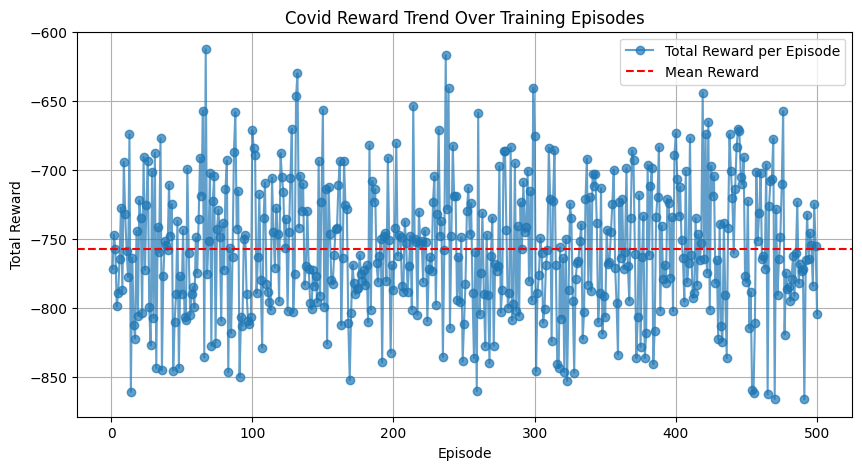

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert reward history into a DataFrame
df = pd.DataFrame({"Episode": range(1, len(reward_history) + 1), "Reward": reward_history})

# Plot the reward trend
plt.figure(figsize=(10, 5))
plt.plot(df["Episode"], df["Reward"], marker="o", linestyle="-", alpha=0.7, label="Total Reward per Episode")
plt.axhline(y=df["Reward"].mean(), color="red", linestyle="--", label="Mean Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Covid Reward Trend Over Training Episodes")
plt.legend()
plt.grid(True)
plt.show()


Train a DQN Agent on the Flu Vaccine Environment:

This section adapts and trains a Deep Q-Network (DQN) agent using the same framework as the COVID-19 agent, but targets the Flu-specific version of the VaccineEnv.

🔁 What’s Different:
The environment is initialized with disease_type="FLU" which adjusts the input state to include:

flu_hospitalization_rate

flu_death_rate

flu_vaccination_coverage

flu_wastage

flu_seasonality_factor

Rewards are collected in flu_reward_history for later visualization and analysis.

⚙️ Core Setup:
Network architecture, learning rate, γ (discount factor), optimizer, and loss function are identical to the COVID training setup.

The agent performs random actions (can later be improved using ε-greedy or policy strategies).

Each episode is limited to 50 steps for efficiency.

This setup allows side-by-side evaluation and comparison between disease-specific policy learning behaviors.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Training parameters
num_episodes = 500
learning_rate = 0.01
gamma = 0.95

# Initialize the COVID-19 RL environment
covid_env = VaccineEnv("FLU")
state_dim = covid_env.state_size
action_dim = covid_env.action_space.n

# Initialize the Q-network and optimizer
q_network = DQN(state_dim, action_dim)
optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

# Initialize a list to store rewards per episode
flu_reward_history = []

# Training loop
for episode in range(num_episodes):
    state = covid_env.reset()
    state = torch.tensor(state, dtype=torch.float32)

    total_reward = 0
    for _ in range(50):  # Limit episode length
        action = random.choice(range(action_dim))  # Random action for now
        next_state, reward, done, _ = covid_env.step(action)

        next_state = torch.tensor(next_state, dtype=torch.float32)
        reward = torch.tensor(reward, dtype=torch.float32)

        # Q-learning update
        target = reward + gamma * torch.max(q_network(next_state))
        prediction = q_network(state)[action]
        loss = loss_fn(prediction, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        state = next_state
        total_reward += reward.item()

        if done:
            break
    # Store reward for visualization
    flu_reward_history.append(total_reward)

    print(f"Episode {episode+1}: Total Reward = {total_reward:.2f}")

print("✅ FLU RL Agent Training Complete")


Episode 1: Total Reward = -493.66
Episode 2: Total Reward = -564.57
Episode 3: Total Reward = -547.18
Episode 4: Total Reward = -560.50
Episode 5: Total Reward = -549.22
Episode 6: Total Reward = -441.47
Episode 7: Total Reward = -544.17
Episode 8: Total Reward = -577.33
Episode 9: Total Reward = -482.08
Episode 10: Total Reward = -555.63
Episode 11: Total Reward = -512.47
Episode 12: Total Reward = -557.32
Episode 13: Total Reward = -582.72
Episode 14: Total Reward = -463.25
Episode 15: Total Reward = -497.83
Episode 16: Total Reward = -533.85
Episode 17: Total Reward = -530.17
Episode 18: Total Reward = -443.35
Episode 19: Total Reward = -573.66
Episode 20: Total Reward = -513.47
Episode 21: Total Reward = -562.36
Episode 22: Total Reward = -546.45
Episode 23: Total Reward = -454.91
Episode 24: Total Reward = -522.80
Episode 25: Total Reward = -516.63
Episode 26: Total Reward = -512.43
Episode 27: Total Reward = -520.62
Episode 28: Total Reward = -561.37
Episode 29: Total Reward = -5

Visualize Flu DQN Agent Training Performance:

This plot displays the total reward per episode during the training of the DQN agent on the Flu vaccine environment. It provides insight into how the agent's performance evolves over time.

📊 Plot Details:
X-axis: Episode number (from 1 to 500).

Y-axis: Total reward the agent received during each episode.

Line Plot: Shows how rewards change across episodes.

Red Dashed Line: Indicates the average reward across all episodes, providing a performance baseline.

Grid and markers: Improve readability and trend visibility.

This helps evaluate:

Whether the agent is learning or fluctuating randomly.

How stable or noisy the reward progression is.

If the environment or hyperparameters might need tuning.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert reward history into a DataFrame
df = pd.DataFrame({"Episode": range(1, len(reward_history) + 1), "Reward": reward_history})

# Plot the reward trend
plt.figure(figsize=(10, 5))
plt.plot(df["Episode"], df["Reward"], marker="o", linestyle="-", alpha=0.7, label="Total Reward per Episode")
plt.axhline(y=df["Reward"].mean(), color="red", linestyle="--", label="Mean Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Covid Reward Trend Over Training Episodes")
plt.legend()
plt.grid(True)
plt.show()


MultiVaccineEnv: Joint COVID-19 and Flu Simulation Environment:

This class defines a custom OpenAI Gym environment that integrates both the COVID-19 and Flu vaccine environments into a single, unified simulation. It enables an agent to make coordinated decisions across two disease domains, reflecting more realistic public health policy scenarios.

🧠 Key Concepts:
Sub-environments:

self.covid_env and self.flu_env are instances of VaccineEnv with "COVID" and "FLU" modes respectively.

Combined Observation Space:

The environment state is the concatenation of COVID and Flu environment states.

Each environment contributes its own health metrics (e.g., hospitalization, death rate, vaccination coverage).

Observation space dimension = covid_state_size + flu_state_size.

Combined Action Space:

There are 6 discrete actions per environment → 12 total combinations (Cartesian product).

The agent selects a joint action:

action % 6 is applied to the COVID env.

action // 6 is applied to the Flu env.

Reward:

The total reward is the sum of the COVID and Flu rewards.

Done Condition:

Episode ends if:

Hospitalization rate (state[0]) in either environment exceeds 0.3, or

Vaccination coverage (state[2]) exceeds 0.9 in both environments.

This setup encourages agents to develop joint vaccine distribution strategies that balance between managing two simultaneous disease dynamics.

In [5]:
# Import MultiVaccineEnv
class MultiVaccineEnv(gym.Env):
    def __init__(self):
        super(MultiVaccineEnv, self).__init__()
        self.covid_env = VaccineEnv("COVID")
        self.flu_env = VaccineEnv("FLU")

        self.state_size = self.covid_env.state_size + self.flu_env.state_size
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_size,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(12)

    def step(self, action):
        covid_action = action % 6  
        flu_action = action // 6  

        covid_state, covid_reward, _, _ = self.covid_env.step(covid_action)
        flu_state, flu_reward, _, _ = self.flu_env.step(flu_action)

        combined_state = np.concatenate([covid_state, flu_state])
        combined_reward = covid_reward + flu_reward  

        done = (covid_state[0] > 0.3 or flu_state[0] > 0.3) or \
               (covid_state[2] > 0.9 and flu_state[2] > 0.9)

        return combined_state, combined_reward, done, {}

    def reset(self):
        covid_state = self.covid_env.reset()
        flu_state = self.flu_env.reset()
        return np.concatenate([covid_state, flu_state])

Test the MultiVaccineEnv with Random Actions:

This cell runs a basic simulation loop using the MultiVaccineEnv, which combines both COVID-19 and Flu vaccine environments. The goal is to test the environment’s behavior and observe how it responds to randomly selected joint actions.

🔁 What This Code Does:
Initializes the MultiVaccineEnv environment.

Resets the environment to get the initial joint state.

Loops for 10 steps:

Randomly samples a joint action from the combined 12-action space.

Executes the action and receives the next state, reward, and done flag.

Prints the new combined state and reward after each step.

Terminates early if the environment's done condition is triggered.

This simulation is useful for:

Verifying that the environment behaves as expected.

Ensuring the action/reward mechanics work before training an agent.

Getting a feel for state transitions and dynamics across both diseases.

In [6]:
# Initialize the Multi-Vaccine RL Agent
multi_vaccine_env = MultiVaccineEnv()

state = multi_vaccine_env.reset()  # Reset environment and get initial state 

for _ in range(10):  # Run for 10 steps
    action = multi_vaccine_env.action_space.sample()  # Take a random action
    next_state, reward, done, _ = multi_vaccine_env.step(action)
    print(f"State: {next_state}, Reward: {reward}")

    if done:
        break  # Stop if the environment ends


State: [0.43424031 0.06443247 0.68799853 0.04098049 0.23815992 0.92095046
 0.56181423 0.12569819 0.10196452 0.76243595 0.52473787 0.87765067
 0.37337676 0.6296871  0.4254987  0.4622906  0.43030401 0.89936557], Reward: -19.874430724504315


Simulate Random Policy on MultiVaccineEnv and Visualize Reward Progression:

This cell runs a simple baseline simulation using a random policy to interact with the MultiVaccineEnv, which combines both COVID-19 and Flu vaccine environments. It tracks how the total reward evolves across episodes, providing a benchmark before applying reinforcement learning agents.

🔁 Simulation Workflow:
Episodes: 500 full episodes of interaction.

Steps per Episode: Limited to 50 to prevent long or infinite episodes.

Action Strategy: Randomly sample from the 12 discrete joint actions.

Reward Accumulation:

Total reward is calculated per episode.

Progress is printed every 50 episodes.

Reward Trend Visualization:

A line plot shows how total reward changes over time.

Useful for evaluating randomness vs. potential learning performance.

This simulation provides a baseline reward distribution which can later be compared to a trained RL agent’s performance.

Episode 0: Total Reward = -29.24
Episode 50: Total Reward = -34.87
Episode 100: Total Reward = -12.05
Episode 150: Total Reward = -17.53
Episode 200: Total Reward = -40.38
Episode 250: Total Reward = -9.74
Episode 300: Total Reward = -42.05
Episode 350: Total Reward = -16.77
Episode 400: Total Reward = -17.60
Episode 450: Total Reward = -21.70


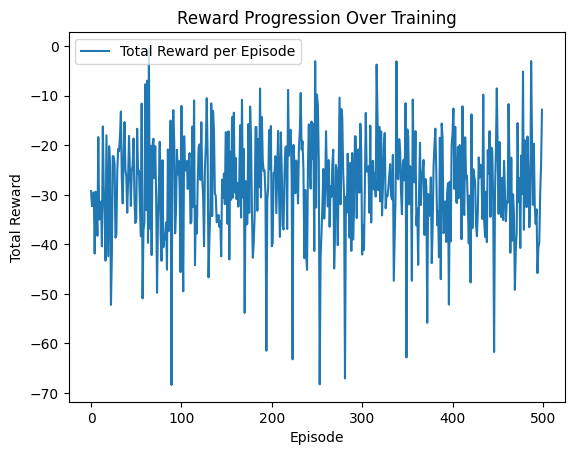

In [12]:
import matplotlib.pyplot as plt

# Track rewards over episodes
num_episodes = 500
reward_history = []

for episode in range(num_episodes):
    state = multi_vaccine_env.reset()
    total_reward = 0

    for _ in range(50):  # Limit steps per episode (adjust as needed)
        action = multi_vaccine_env.action_space.sample()  # Take a random action
        next_state, reward, done, _ = multi_vaccine_env.step(action)
        total_reward += reward  # Accumulate reward

        if done:
            break  # Stop if episode ends

    reward_history.append(total_reward)  # Store reward

    # Print progress every 50 episodes
    if episode % 50 == 0:
        print(f"Episode {episode}: Total Reward = {total_reward:.2f}")

# Plot reward progression
plt.plot(reward_history, label="Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Progression Over Training")
plt.legend()
plt.show()


Visualize Action Distribution in MultiVaccineEnv (Random Policy):

This cell creates a bar chart showing the distribution of actions sampled over 100 steps in the MultiVaccineEnv. It helps assess whether all actions in the discrete joint action space (0–11) are being explored equally under a random policy.

🎯 Why This Matters:
Ensures the environment’s action space is being properly sampled.

Useful for debugging the random policy before implementing ε-greedy or trained agents.

Helps interpret how actions are mapped across both COVID and Flu sub-environments.

🧪 How It Works:
Runs the environment for 100 steps, taking a random action at each step.

Collects each sampled action into a list.

Converts that list into a Pandas DataFrame for easy plotting.

Uses Seaborn’s countplot to visualize how often each action was selected.

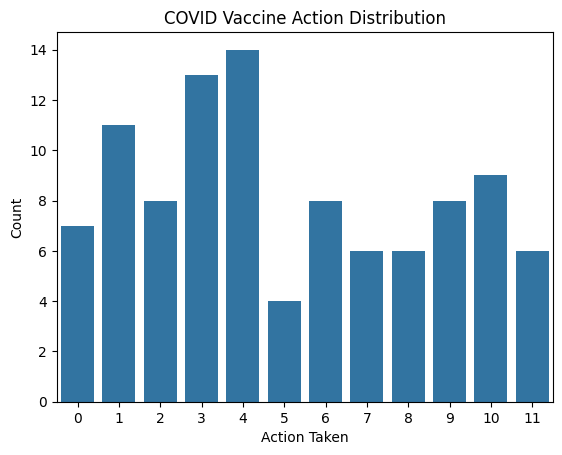

In [13]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt

action_counts = []

for _ in range(100):  # Run 100 steps
    action = multi_vaccine_env.action_space.sample()  # Sample action
    action_counts.append(action)  # Directly append the integer action

# Convert to DataFrame for plotting
action_df = pd.DataFrame({"Action": action_counts})

# ✅ Visualize action distribution
sns.countplot(data=action_df, x="Action")
plt.xlabel("Action Taken")
plt.ylabel("Count")
plt.title("COVID Vaccine Action Distribution")
plt.show()


Dynamic Visualization: COVID-19 Vaccine Coverage & Routing Optimization (U.S. States Network):

This cell creates a geographic simulation of COVID-19 vaccine distribution across all U.S. states. The network graph updates dynamically over several steps to reflect changing coverage and optimized distribution routes.

🌍 What This Simulation Shows:
U.S. states represented as nodes on a map, positioned based on approximate latitude and longitude.

Node color intensity reflects each state’s current vaccine coverage (from the environment).

Edges represent optimized vaccine distribution routes:

Based on minimum spanning tree (MST).

Enhanced with shortest paths from vaccine hubs (California, Texas, New York).

The graph updates over multiple time steps, simulating real-time dynamics of distribution efforts.

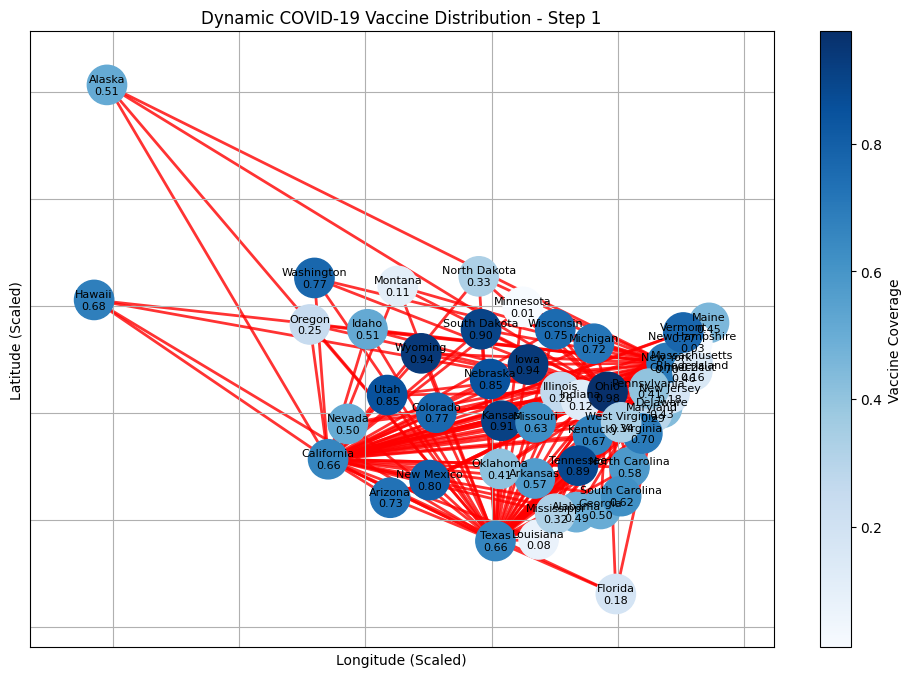


COVID Vaccine Coverage Table - Step 1

         State  COVID Vaccine Coverage
       Alabama                0.487501
        Alaska                0.508932
       Arizona                0.730109
      Arkansas                0.569652
    California                0.661680
      Colorado                0.765875
   Connecticut                0.457285
      Delaware                0.433800
       Florida                0.182336
       Georgia                0.501583
        Hawaii                0.682945
         Idaho                0.512313
      Illinois                0.261841
       Indiana                0.123687
          Iowa                0.936318
        Kansas                0.914932
      Kentucky                0.673913
     Louisiana                0.078800
         Maine                0.452469
      Maryland                0.286163
 Massachusetts                0.244516
      Michigan                0.718788
     Minnesota                0.011115
   Mississippi          

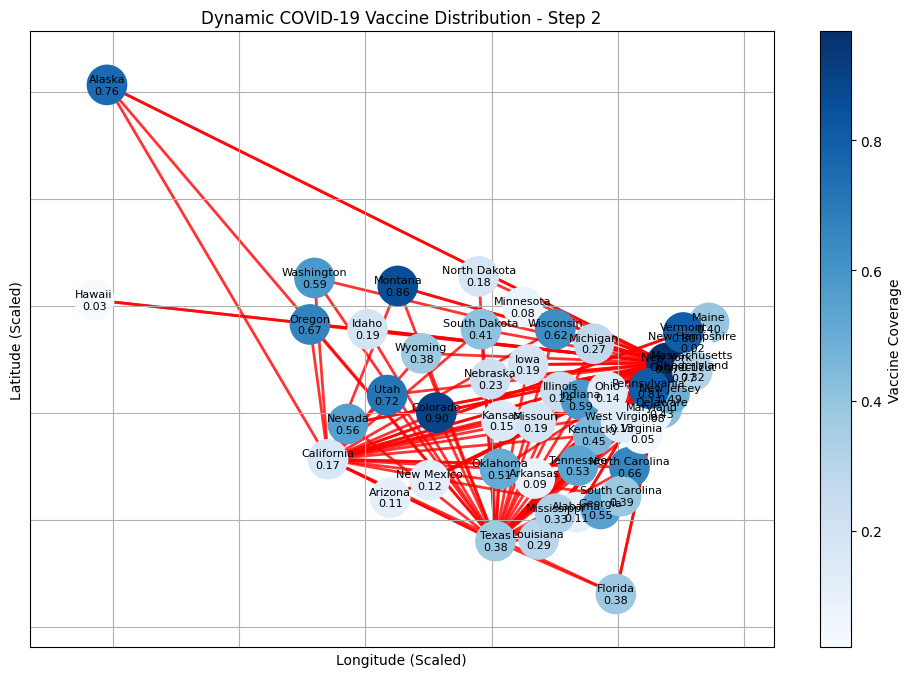


COVID Vaccine Coverage Table - Step 2

         State  COVID Vaccine Coverage
       Alabama                0.106862
        Alaska                0.760077
       Arizona                0.110678
      Arkansas                0.089396
    California                0.169956
      Colorado                0.900535
   Connecticut                0.768105
      Delaware                0.426247
       Florida                0.379535
       Georgia                0.549317
        Hawaii                0.029236
         Idaho                0.193286
      Illinois                0.235715
       Indiana                0.589397
          Iowa                0.189538
        Kansas                0.149718
      Kentucky                0.452269
     Louisiana                0.291641
         Maine                0.396302
      Maryland                0.081836
 Massachusetts                0.171934
      Michigan                0.274723
     Minnesota                0.076592
   Mississippi          

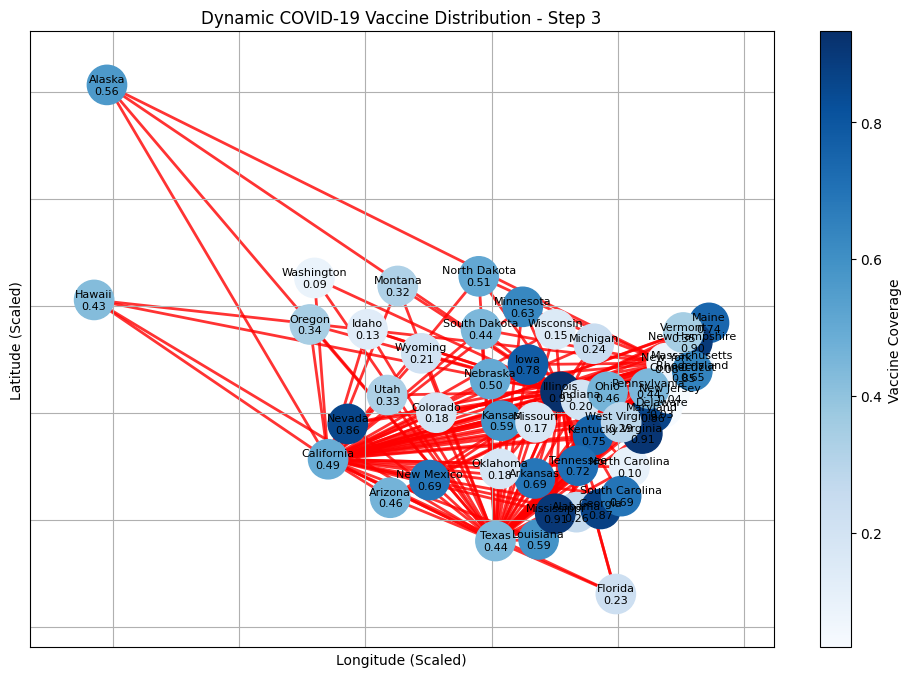


COVID Vaccine Coverage Table - Step 3

         State  COVID Vaccine Coverage
       Alabama                0.263039
        Alaska                0.563634
       Arizona                0.464026
      Arkansas                0.688199
    California                0.492254
      Colorado                0.183475
   Connecticut                0.852450
      Delaware                0.031969
       Florida                0.225675
       Georgia                0.872971
        Hawaii                0.427236
         Idaho                0.134337
      Illinois                0.932608
       Indiana                0.195916
          Iowa                0.776393
        Kansas                0.589412
      Kentucky                0.752599
     Louisiana                0.590782
         Maine                0.743496
      Maryland                0.862959
 Massachusetts                0.072735
      Michigan                0.244281
     Minnesota                0.626833
   Mississippi          

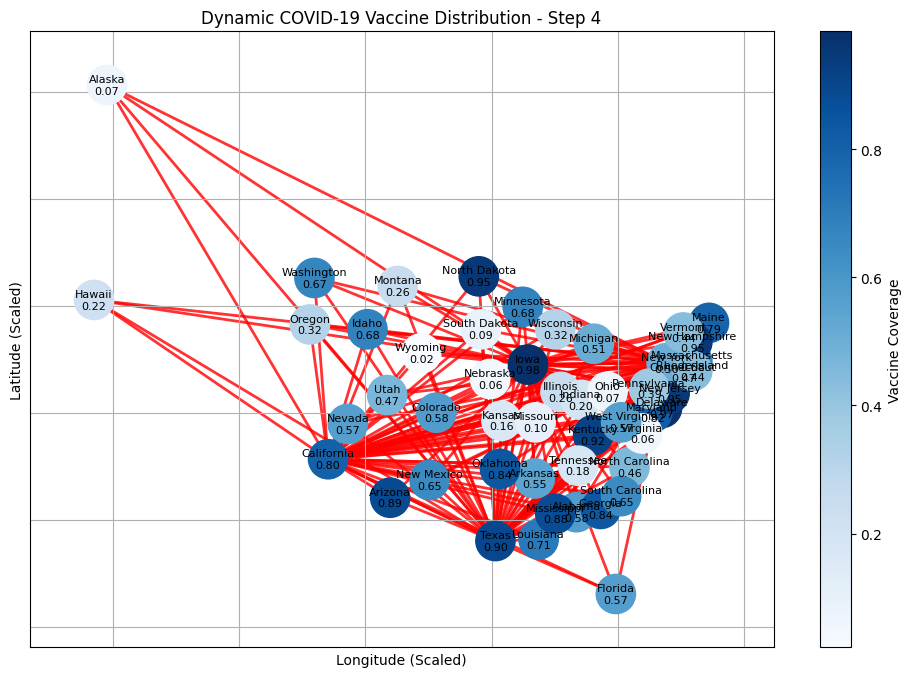


COVID Vaccine Coverage Table - Step 4

         State  COVID Vaccine Coverage
       Alabama                0.580598
        Alaska                0.072234
       Arizona                0.889706
      Arkansas                0.546334
    California                0.801170
      Colorado                0.580875
   Connecticut                0.470604
      Delaware                0.974055
       Florida                0.571161
       Georgia                0.837014
        Hawaii                0.224252
         Idaho                0.681233
      Illinois                0.257648
       Indiana                0.198191
          Iowa                0.983883
        Kansas                0.164562
      Kentucky                0.923076
     Louisiana                0.713270
         Maine                0.794561
      Maryland                0.816095
 Massachusetts                0.679735
      Michigan                0.507898
     Minnesota                0.679819
   Mississippi          

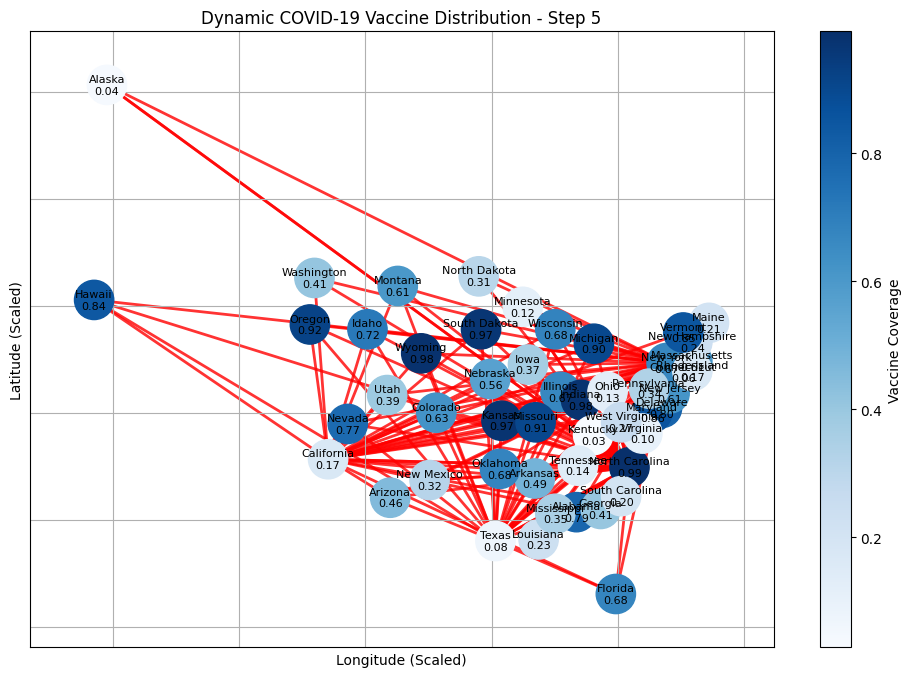


COVID Vaccine Coverage Table - Step 5

         State  COVID Vaccine Coverage
       Alabama                0.789046
        Alaska                0.042187
       Arizona                0.459882
      Arkansas                0.490024
    California                0.173287
      Colorado                0.625476
   Connecticut                0.063440
      Delaware                0.797979
       Florida                0.676746
       Georgia                0.407542
        Hawaii                0.840297
         Idaho                0.721532
      Illinois                0.670589
       Indiana                0.976208
          Iowa                0.369814
        Kansas                0.974601
      Kentucky                0.027994
     Louisiana                0.233993
         Maine                0.209657
      Maryland                0.859421
 Massachusetts                0.612829
      Michigan                0.902611
     Minnesota                0.121376
   Mississippi          

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

env = MultiVaccineEnv()

# ✅ Adjust positions: Keep Alaska & Hawaii fixed, center and spread the lower 48
scale_factor = 3  # Scaling factor for visualization
center_shift = (-98, 39)  # Rough center of the continental US to shift states

state_coords = {}
raw_coords = {
    'Alabama': (32.8, -86.8), 'Alaska': (61.3, -152.4), 'Arizona': (33.7, -111.4),
    'Arkansas': (34.9, -92.3), 'California': (36.1, -119.6), 'Colorado': (39.0, -105.3),
    'Connecticut': (41.5, -72.7), 'Delaware': (39.3, -75.5), 'Florida': (27.7, -81.6),
    'Georgia': (33.0, -83.6), 'Hawaii': (21.09, -157.49), 'Idaho': (44.2, -114.4),
    'Illinois': (40.3, -88.9), 'Indiana': (39.8, -86.2), 'Iowa': (42.0, -93.2),
    'Kansas': (38.5, -96.7), 'Kentucky': (37.6, -84.6), 'Louisiana': (31.1, -91.8),
    'Maine': (44.6, -69.3), 'Maryland': (39.0, -76.8), 'Massachusetts': (42.2, -71.5),
    'Michigan': (43.3, -84.5), 'Minnesota': (45.6, -93.9), 'Mississippi': (32.7, -89.6),
    'Missouri': (38.4, -92.2), 'Montana': (46.9, -110.4), 'Nebraska': (41.1, -98.2),
    'Nevada': (38.3, -117.0), 'New Hampshire': (43.4, -71.5), 'New Jersey': (40.2, -74.5),
    'New Mexico': (34.8, -106.2), 'New York': (42.1, -74.9), 'North Carolina': (35.6, -79.8),
    'North Dakota': (47.5, -99.7), 'Ohio': (40.3, -82.7), 'Oklahoma': (35.5, -96.9),
    'Oregon': (44.5, -122.0), 'Pennsylvania': (40.5, -77.2), 'Rhode Island': (41.6, -71.5),
    'South Carolina': (33.8, -80.9), 'South Dakota': (44.2, -99.4), 'Tennessee': (35.7, -86.6),
    'Texas': (31.0, -97.5), 'Utah': (40.1, -111.8), 'Vermont': (44.0, -72.7),
    'Virginia': (37.7, -78.1), 'Washington': (47.4, -121.4), 'West Virginia': (38.4, -80.9),
    'Wisconsin': (44.2, -89.6), 'Wyoming': (42.7, -107.3)
}

for state, (lat, lon) in raw_coords.items():
    if state in ['Alaska', 'Hawaii']:
        state_coords[state] = (lon, lat)  # Keep original positions
    else:
        state_coords[state] = ((lon - center_shift[0]) * scale_factor, (lat - center_shift[1]) * scale_factor)

# ✅ Create a Fully Connected Graph
G_covid = nx.complete_graph(state_coords.keys())

# ✅ Special connections for Alaska and Hawaii
G_covid.add_edges_from([
    ("Alaska", "Washington"), ("Alaska", "California"),
    ("Hawaii", "California"), ("Hawaii", "Texas")
])

# ✅ Function to update vaccine coverage dynamically
def update_vaccine_coverage():
    return {state: env.step(random.randint(0, 11))[0][2] for state in G_covid.nodes()}

# ✅ Function to compute MST and Dijkstra's paths
def compute_optimized_routes():
    for u, v in G_covid.edges():
        weight = 1 / (0.1 + (state_covid_coverage[u] + state_covid_coverage[v]) / 2)
        G_covid[u][v]['weight'] = weight

    mst = nx.minimum_spanning_tree(G_covid, weight='weight')

    vaccine_hubs = ["California", "Texas", "New York"]
    optimal_routes = set(mst.edges())
    for hub in vaccine_hubs:
        shortest_paths = nx.single_source_dijkstra_path(G_covid, hub, weight='weight')
        for target in shortest_paths:
            path = shortest_paths[target]
            for i in range(len(path) - 1):
                optimal_routes.add((path[i], path[i+1]))

    return optimal_routes

# ✅ Visualization loop
for step in range(5):
    plt.figure(figsize=(12, 8))
    
    state_covid_coverage = update_vaccine_coverage()
    optimal_routes = compute_optimized_routes()

    pos = {state: (coords[0], coords[1]) for state, coords in state_coords.items()}

    node_colors = [state_covid_coverage[state] for state in G_covid.nodes()]
    nodes = nx.draw_networkx_nodes(G_covid, pos, node_color=node_colors, cmap="Blues", node_size=800)
    nx.draw_networkx_edges(G_covid, pos, edgelist=optimal_routes, edge_color="red", width=2, alpha=0.8)
    
    state_labels = {state: f"{state}\n{state_covid_coverage[state]:.2f}" for state in G_covid.nodes()}
    nx.draw_networkx_labels(G_covid, pos, labels=state_labels, font_size=8, font_color="black")

    cbar = plt.colorbar(nodes)
    cbar.set_label("Vaccine Coverage")

    plt.title(f"Dynamic COVID-19 Vaccine Distribution - Step {step + 1}")
    plt.xlabel("Longitude (Scaled)")
    plt.ylabel("Latitude (Scaled)")
    plt.grid(True)
    plt.show()

    df_covid = pd.DataFrame(state_covid_coverage.items(), columns=["State", "COVID Vaccine Coverage"])
    print(f"\nCOVID Vaccine Coverage Table - Step {step + 1}\n")
    print(df_covid.to_string(index=False))

    time.sleep(1)


Simulated U.S. State Vaccine Coverage Over Time (Geographic Network Graph):

This section visualizes vaccine coverage levels across all U.S. states using a geographic network graph that updates dynamically over time. It provides a spatial perspective of vaccine rollout patterns and neighboring relationships between states.



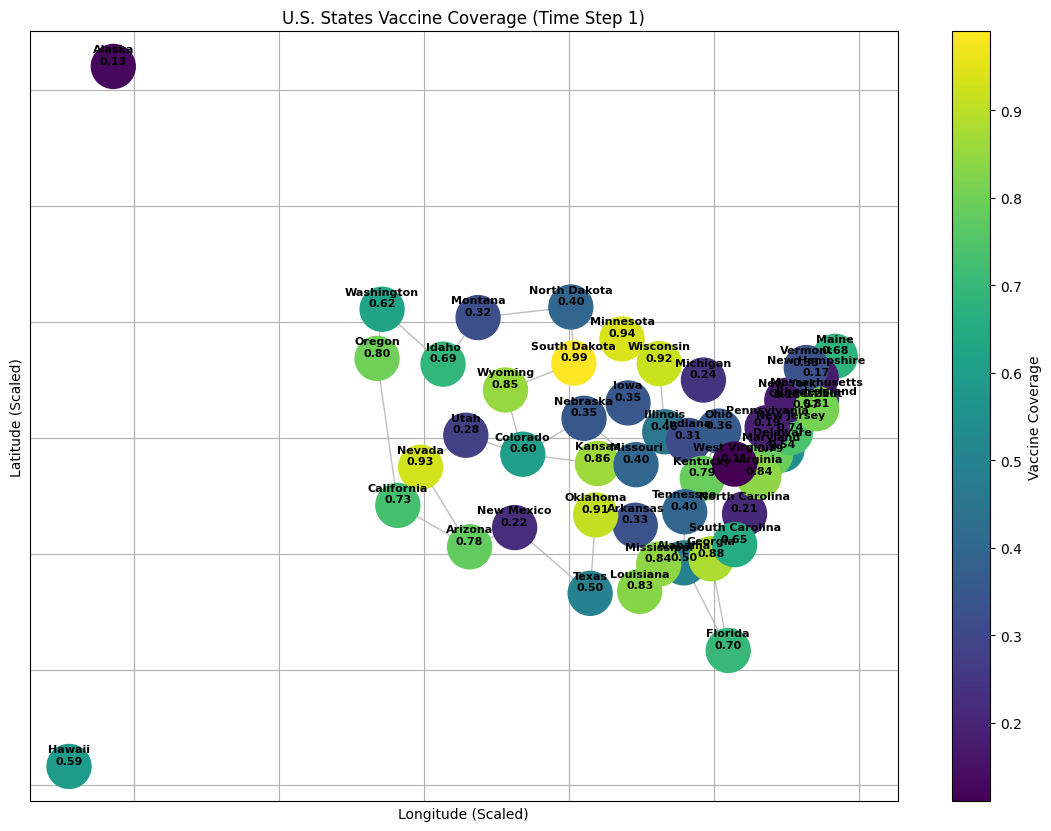


Vaccine Coverage Table (Time Step 1)

         State  Vaccine Coverage
       Alabama              0.50
        Alaska              0.13
       Arizona              0.78
      Arkansas              0.33
    California              0.73
      Colorado              0.60
   Connecticut              0.57
      Delaware              0.54
       Florida              0.70
       Georgia              0.88
        Hawaii              0.59
         Idaho              0.69
      Illinois              0.46
       Indiana              0.31
          Iowa              0.35
        Kansas              0.86
      Kentucky              0.79
     Louisiana              0.83
         Maine              0.68
      Maryland              0.79
 Massachusetts              0.25
      Michigan              0.24
     Minnesota              0.94
   Mississippi              0.84
      Missouri              0.40
       Montana              0.32
      Nebraska              0.35
        Nevada              0.93
 New

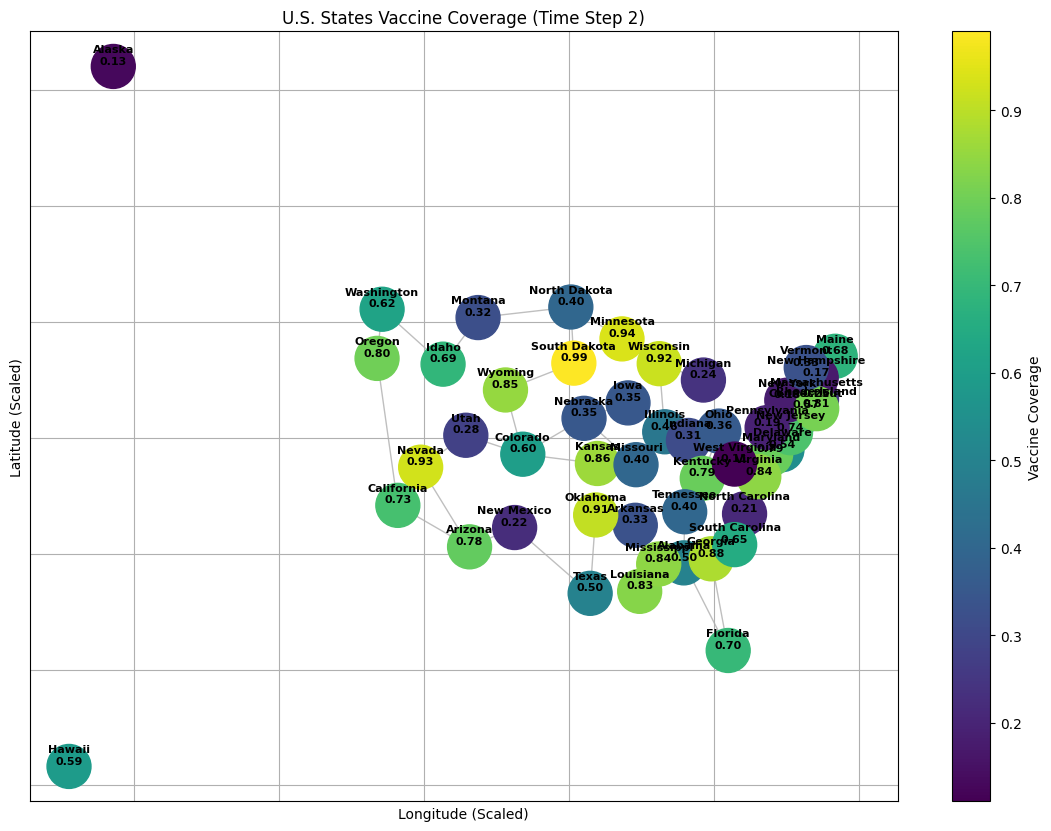


Vaccine Coverage Table (Time Step 2)

         State  Vaccine Coverage
       Alabama              0.50
        Alaska              0.13
       Arizona              0.78
      Arkansas              0.33
    California              0.73
      Colorado              0.60
   Connecticut              0.57
      Delaware              0.54
       Florida              0.70
       Georgia              0.88
        Hawaii              0.59
         Idaho              0.69
      Illinois              0.46
       Indiana              0.31
          Iowa              0.35
        Kansas              0.86
      Kentucky              0.79
     Louisiana              0.83
         Maine              0.68
      Maryland              0.79
 Massachusetts              0.25
      Michigan              0.24
     Minnesota              0.94
   Mississippi              0.84
      Missouri              0.40
       Montana              0.32
      Nebraska              0.35
        Nevada              0.93
 New

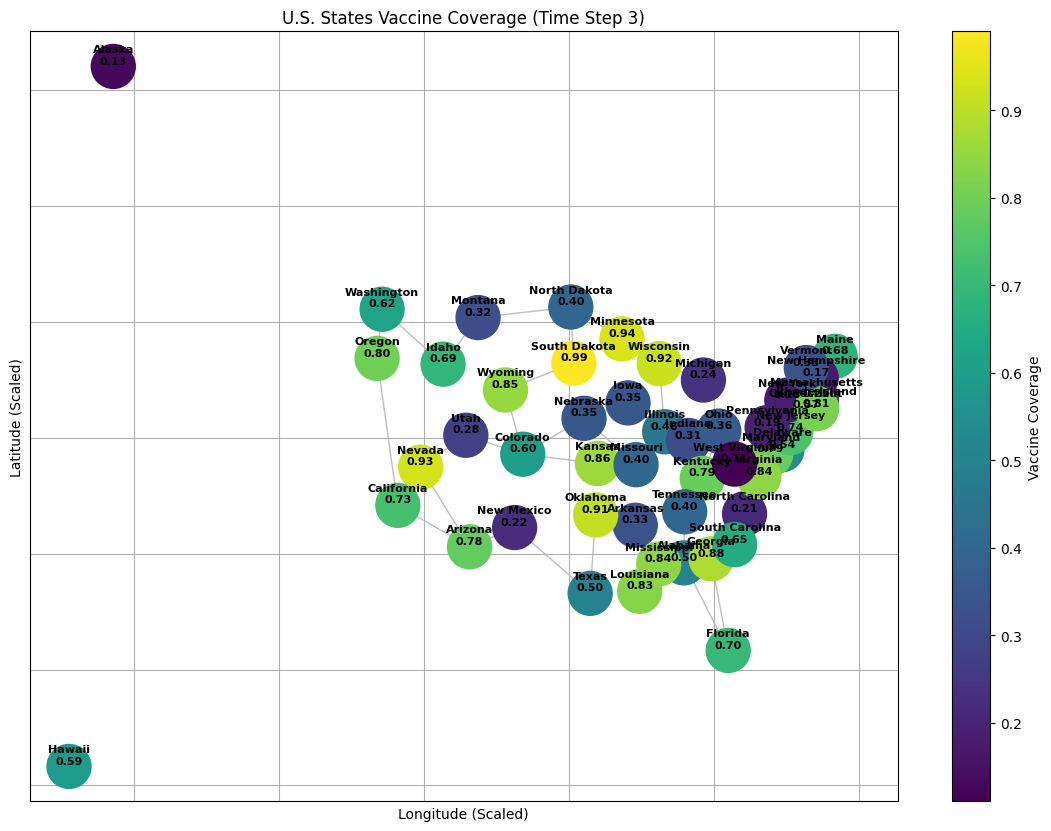


Vaccine Coverage Table (Time Step 3)

         State  Vaccine Coverage
       Alabama              0.50
        Alaska              0.13
       Arizona              0.78
      Arkansas              0.33
    California              0.73
      Colorado              0.60
   Connecticut              0.57
      Delaware              0.54
       Florida              0.70
       Georgia              0.88
        Hawaii              0.59
         Idaho              0.69
      Illinois              0.46
       Indiana              0.31
          Iowa              0.35
        Kansas              0.86
      Kentucky              0.79
     Louisiana              0.83
         Maine              0.68
      Maryland              0.79
 Massachusetts              0.25
      Michigan              0.24
     Minnesota              0.94
   Mississippi              0.84
      Missouri              0.40
       Montana              0.32
      Nebraska              0.35
        Nevada              0.93
 New

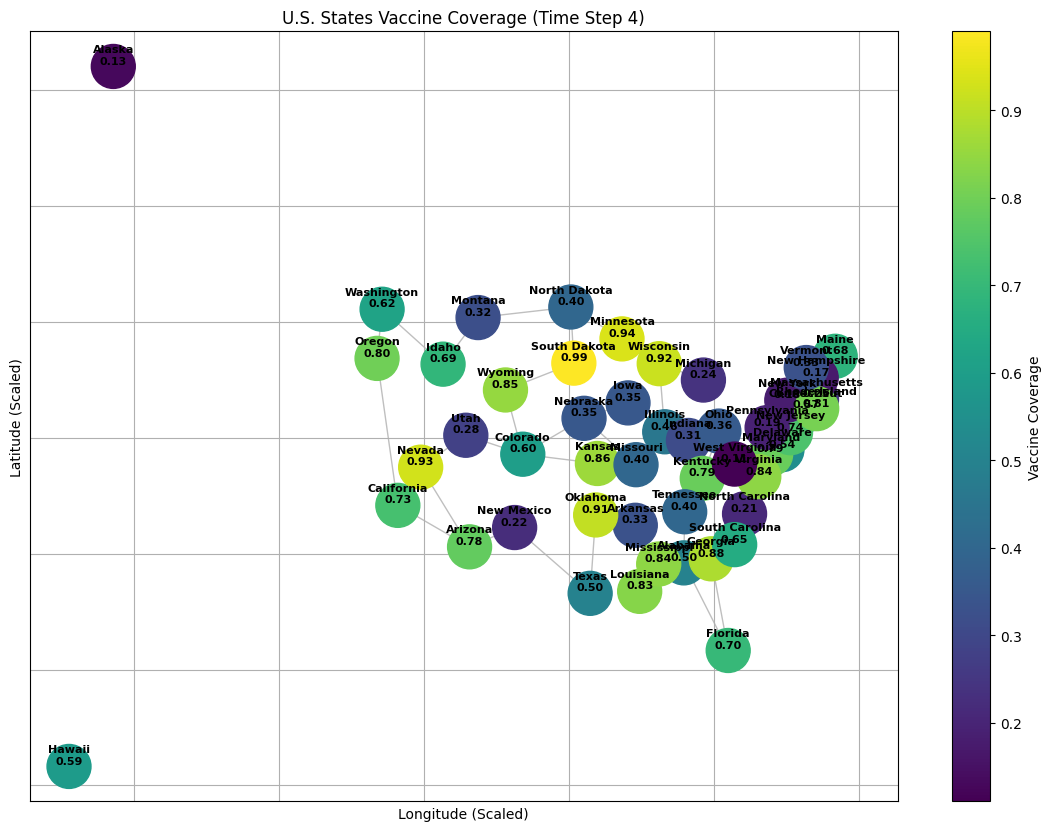


Vaccine Coverage Table (Time Step 4)

         State  Vaccine Coverage
       Alabama              0.50
        Alaska              0.13
       Arizona              0.78
      Arkansas              0.33
    California              0.73
      Colorado              0.60
   Connecticut              0.57
      Delaware              0.54
       Florida              0.70
       Georgia              0.88
        Hawaii              0.59
         Idaho              0.69
      Illinois              0.46
       Indiana              0.31
          Iowa              0.35
        Kansas              0.86
      Kentucky              0.79
     Louisiana              0.83
         Maine              0.68
      Maryland              0.79
 Massachusetts              0.25
      Michigan              0.24
     Minnesota              0.94
   Mississippi              0.84
      Missouri              0.40
       Montana              0.32
      Nebraska              0.35
        Nevada              0.93
 New

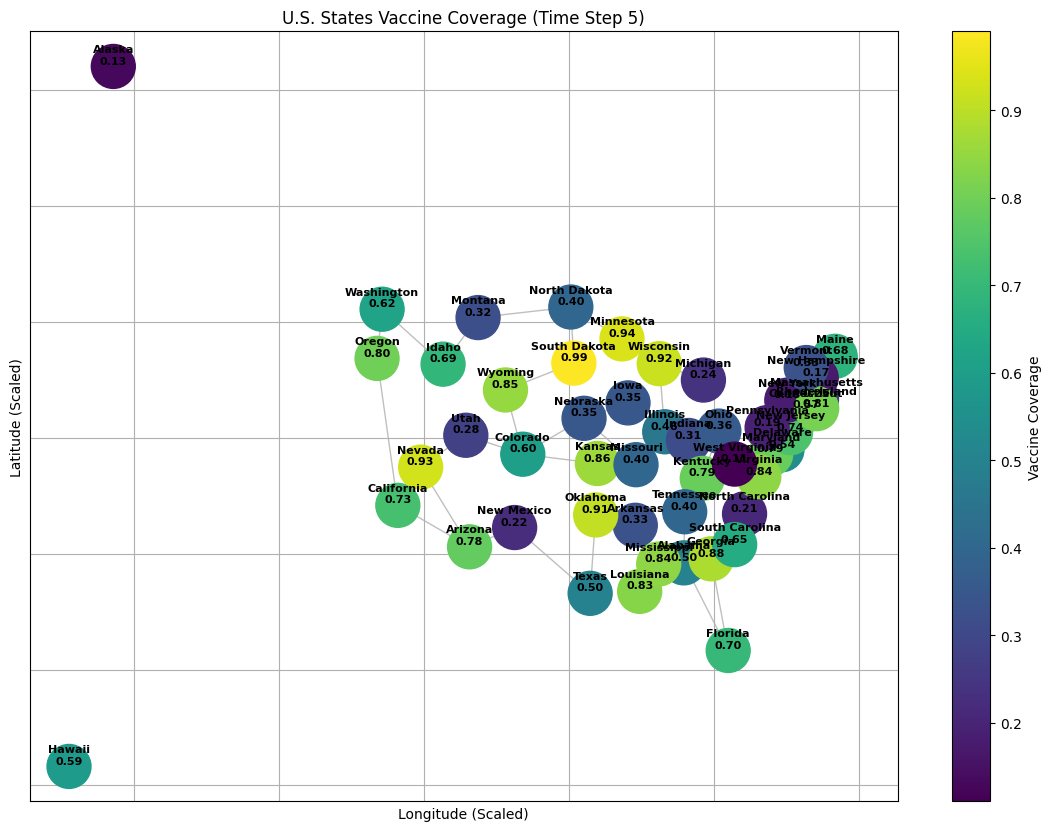


Vaccine Coverage Table (Time Step 5)

         State  Vaccine Coverage
       Alabama              0.50
        Alaska              0.13
       Arizona              0.78
      Arkansas              0.33
    California              0.73
      Colorado              0.60
   Connecticut              0.57
      Delaware              0.54
       Florida              0.70
       Georgia              0.88
        Hawaii              0.59
         Idaho              0.69
      Illinois              0.46
       Indiana              0.31
          Iowa              0.35
        Kansas              0.86
      Kentucky              0.79
     Louisiana              0.83
         Maine              0.68
      Maryland              0.79
 Massachusetts              0.25
      Michigan              0.24
     Minnesota              0.94
   Mississippi              0.84
      Missouri              0.40
       Montana              0.32
      Nebraska              0.35
        Nevada              0.93
 New

In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import time

env = MultiVaccineEnv()
# Define state coordinates (longitude, latitude) and apply scaling to spread out states
scale_factor = 3  # Adjust this value to spread states apart
state_coords = {
    state: (lat * scale_factor, lon * scale_factor)  # Scale latitude and longitude
    for state, (lat, lon) in {
        'Alabama': (32.806671, -86.791130), 'Alaska': (61.370716, -152.404419), 'Arizona': (33.729759, -111.431221),
        'Arkansas': (34.969704, -92.373123), 'California': (36.116203, -119.681564), 'Colorado': (39.059811, -105.311104),
        'Connecticut': (41.597782, -72.755371), 'Delaware': (39.318523, -75.507141), 'Florida': (27.766279, -81.686783),
        'Georgia': (33.040619, -83.643074), 'Hawaii': (21.094318, -157.498337), 'Idaho': (44.240459, -114.478828),
        'Illinois': (40.349457, -88.986137), 'Indiana': (39.849426, -86.258278), 'Iowa': (42.011539, -93.210526),
        'Kansas': (38.526600, -96.726486), 'Kentucky': (37.668140, -84.670067), 'Louisiana': (31.169546, -91.867805),
        'Maine': (44.693947, -69.381927), 'Maryland': (39.063946, -76.802101), 'Massachusetts': (42.230171, -71.530106),
        'Michigan': (43.326618, -84.536095), 'Minnesota': (45.694454, -93.900192), 'Mississippi': (32.741646, -89.678696),
        'Missouri': (38.456085, -92.288368), 'Montana': (46.921925, -110.454353), 'Nebraska': (41.125370, -98.268082),
        'Nevada': (38.313515, -117.055374), 'New Hampshire': (43.452492, -71.563896), 'New Jersey': (40.298904, -74.521011),
        'New Mexico': (34.840515, -106.248482), 'New York': (42.165726, -74.948051), 'North Carolina': (35.630066, -79.806419),
        'North Dakota': (47.528912, -99.784012), 'Ohio': (40.388783, -82.764915), 'Oklahoma': (35.565342, -96.928917),
        'Oregon': (44.572021, -122.070938), 'Pennsylvania': (40.590752, -77.209755), 'Rhode Island': (41.680893, -71.511780),
        'South Carolina': (33.856892, -80.945007), 'South Dakota': (44.299782, -99.438828), 'Tennessee': (35.747845, -86.692345),
        'Texas': (31.054487, -97.563461), 'Utah': (40.150032, -111.862434), 'Vermont': (44.045876, -72.710686),
        'Virginia': (37.769337, -78.169968), 'Washington': (47.400902, -121.490494), 'West Virginia': (38.491226, -80.954456),
        'Wisconsin': (44.268543, -89.616508), 'Wyoming': (42.755966, -107.302490)
    }.items()
}

# Define neighboring states as edges
state_edges = [
    ("Alabama", "Georgia"), ("Alabama", "Tennessee"), ("Alabama", "Mississippi"),
    ("Arizona", "California"), ("Arizona", "Nevada"), ("Arizona", "New Mexico"),
    ("California", "Oregon"), ("California", "Nevada"), ("Colorado", "Utah"),
    ("Colorado", "Kansas"), ("Colorado", "Nebraska"), ("Colorado", "Wyoming"),
    ("Florida", "Georgia"), ("Florida", "Alabama"), ("Georgia", "South Carolina"),
    ("Idaho", "Montana"), ("Idaho", "Washington"), ("Illinois", "Indiana"),
    ("Illinois", "Iowa"), ("Illinois", "Missouri"), ("Indiana", "Ohio"),
    ("Iowa", "Nebraska"), ("Kansas", "Missouri"), ("Kentucky", "Ohio"),
    ("Louisiana", "Mississippi"), ("Maine", "New Hampshire"), ("Maryland", "Pennsylvania"),
    ("Massachusetts", "Rhode Island"), ("Michigan", "Wisconsin"), ("Minnesota", "Wisconsin"),
    ("Missouri", "Nebraska"), ("Montana", "North Dakota"), ("New Mexico", "Texas"),
    ("New York", "New Jersey"), ("North Carolina", "South Carolina"), ("Ohio", "West Virginia"),
    ("Oklahoma", "Texas"), ("Oregon", "Washington"), ("Tennessee", "Kentucky"),
    ("Virginia", "West Virginia"), ("Wyoming", "South Dakota"), ("South Dakota", "North Dakota"),
    ("North Dakota", "Minnesota"), ("Wisconsin", "Illinois"), ("Nevada", "Utah")
]

# Create a graph
G = nx.Graph()
for state, (lat, lon) in state_coords.items():
    G.add_node(state, pos=(lon, lat))
G.add_edges_from(state_edges)

# Initialize vaccine coverage (randomized)
state_vaccine_coverage = {state: round(random.uniform(0.1, 1.0), 2) for state in G.nodes()}

# Function to update vaccine coverage dynamically
def update_vaccine_coverage(state_vaccine_coverage):
    for state in state_vaccine_coverage:
        change = random.uniform(-0.02, 0.05)  # Allow coverage to increase/decrease slightly
        # state_vaccine_coverage[state] = round(max(0, min(1, state_vaccine_coverage[state] + change)), 2)  # Keep in [0,1]
        
    return state_vaccine_coverage

# Visualization loop (run multiple frames to show updates over time)
for step in range(5):  # Number of time steps
    plt.figure(figsize=(14, 10))  # Increase figure size for better visibility
    
    # Update vaccine coverage
    state_vaccine_coverage = update_vaccine_coverage(state_vaccine_coverage)

    # Get node colors based on updated vaccine coverage
    node_colors = [state_vaccine_coverage[state] for state in G.nodes()]
    
    # Get positions
    pos = nx.get_node_attributes(G, 'pos')

    # Draw the graph
    nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.viridis, node_size=1000)
    edges = nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.5)

    # Create labels with state names and vaccine coverage below
    state_labels = {state: f"{state}\n{state_vaccine_coverage[state]:.2f}" for state in G.nodes()}
    
    # Adjust label position to avoid overlap
    label_pos = {state: (coords[0], coords[1] + 2) for state, coords in pos.items()}
    
    # Draw labels (state names and coverage below)
    nx.draw_networkx_labels(G, label_pos, labels=state_labels, font_size=8, font_color="black", font_weight="bold")

    # Add colorbar
    cbar = plt.colorbar(nodes)
    cbar.set_label("Vaccine Coverage")

    plt.title(f"U.S. States Vaccine Coverage (Time Step {step + 1})")
    plt.xlabel("Longitude (Scaled)")
    plt.ylabel("Latitude (Scaled)")
    plt.grid(True)
    plt.show()
    
    # Create a DataFrame that matches the current vaccine coverage values
    df = pd.DataFrame(list(state_vaccine_coverage.items()), columns=["State", "Vaccine Coverage"])
    df = df.sort_values(by="State")  # Sort for consistency
    print(f"\nVaccine Coverage Table (Time Step {step + 1})\n")
    print(df.to_string(index=False))

    time.sleep(1)  # Pause before next update

U.S. COVID-19 Vaccine Distribution Optimization with Network Routing:

This cell runs a national-scale simulation that models how COVID-19 vaccine coverage evolves and optimizes distribution routes across all U.S. states over time using graph theory and geographic visualization.

🗺️ What It Models:
U.S. States as Nodes: Each state is mapped geographically using scaled latitude/longitude coordinates.

Fully Connected Network: All states are initially connected to each other (as if all distribution routes were possible).

Special Routes: Direct "air/sea" routes are added from Alaska and Hawaii to mainland hubs (California, Texas, Washington).

Dynamic Simulation: Vaccine coverage is updated at every time step using the environment’s internal logic (MultiVaccineEnv).

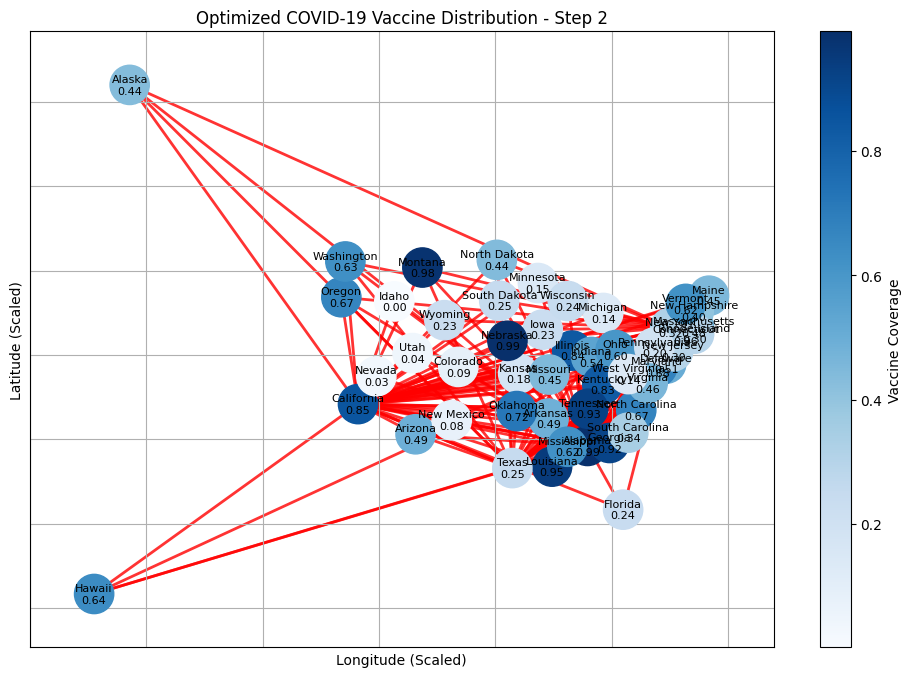

,State,COVID Vaccine Coverage
0,Alabama,0.992080
1,Alaska,0.435171
2,Arizona,0.490028
3,Arkansas,0.485475
4,California,0.851193
5,Colorado,0.086703
6,Connecticut,0.963242
7,Delaware,0.505165
8,Florida,0.240342
9,Georgia,0.917310


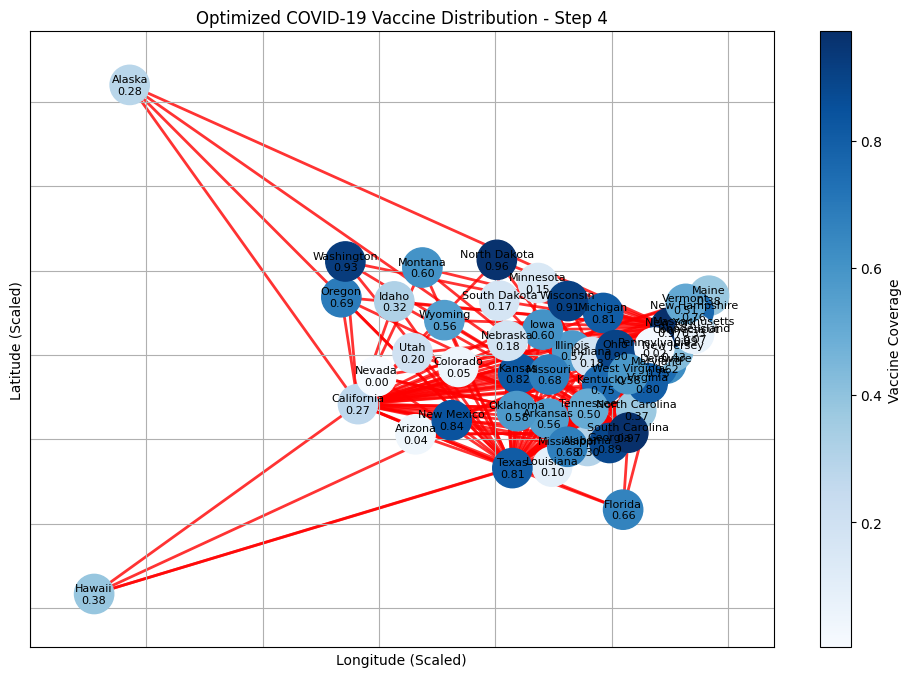

,State,COVID Vaccine Coverage
0,Alabama,0.301711
1,Alaska,0.284241
2,Arizona,0.042412
3,Arkansas,0.557463
4,California,0.267840
5,Colorado,0.050906
6,Connecticut,0.092613
7,Delaware,0.621052
8,Florida,0.662069
9,Georgia,0.890844


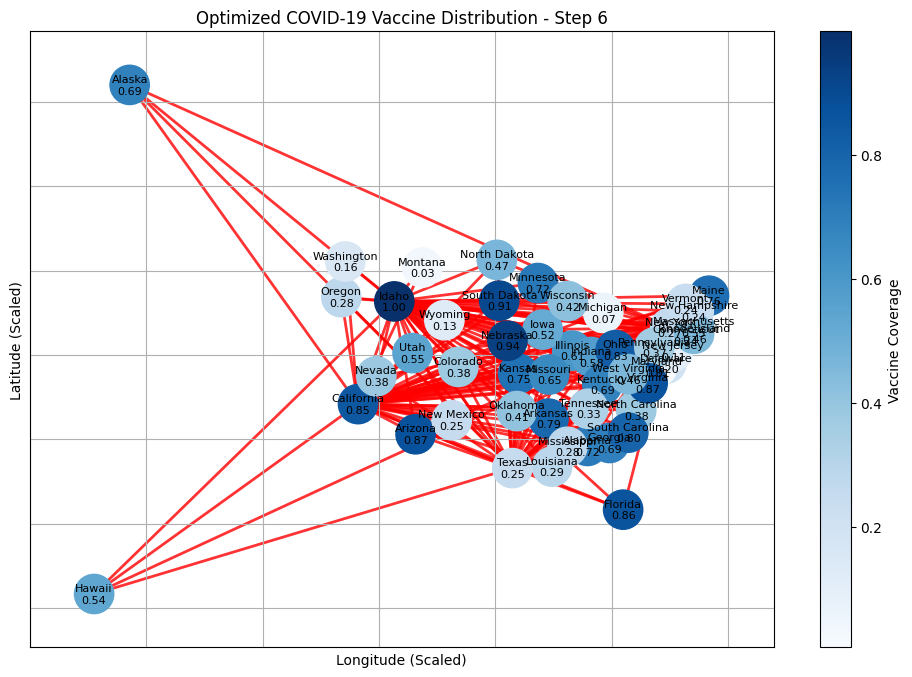

,State,COVID Vaccine Coverage
0,Alabama,0.718835
1,Alaska,0.691558
2,Arizona,0.872133
3,Arkansas,0.787615
4,California,0.845539
5,Colorado,0.380433
6,Connecticut,0.237348
7,Delaware,0.197661
8,Florida,0.860843
9,Georgia,0.693068


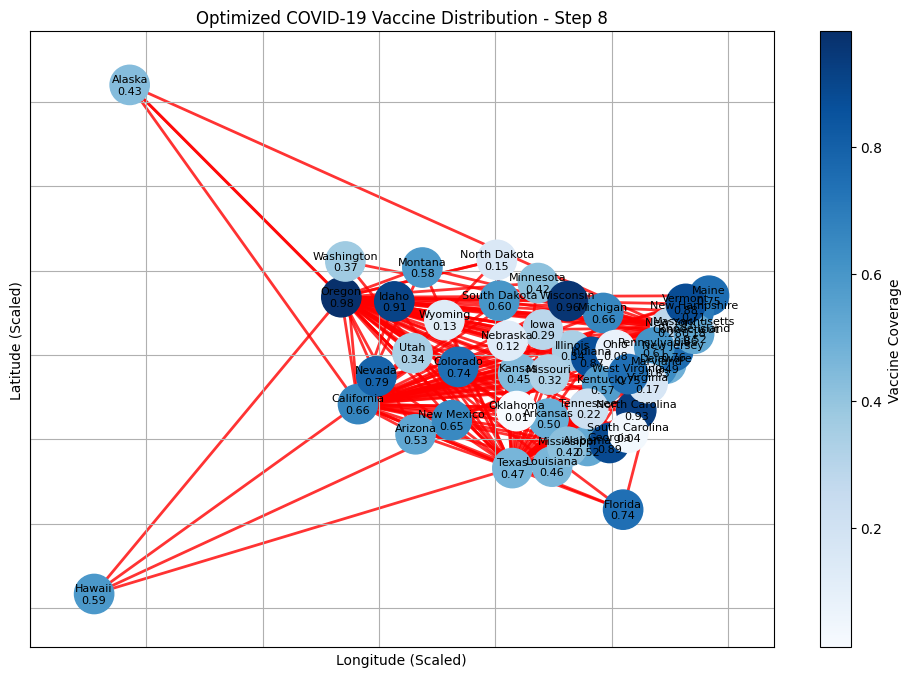

,State,COVID Vaccine Coverage
0,Alabama,0.517746
1,Alaska,0.433563
2,Arizona,0.528178
3,Arkansas,0.500087
4,California,0.664841
5,Colorado,0.743740
6,Connecticut,0.858916
7,Delaware,0.487601
8,Florida,0.743247
9,Georgia,0.887447


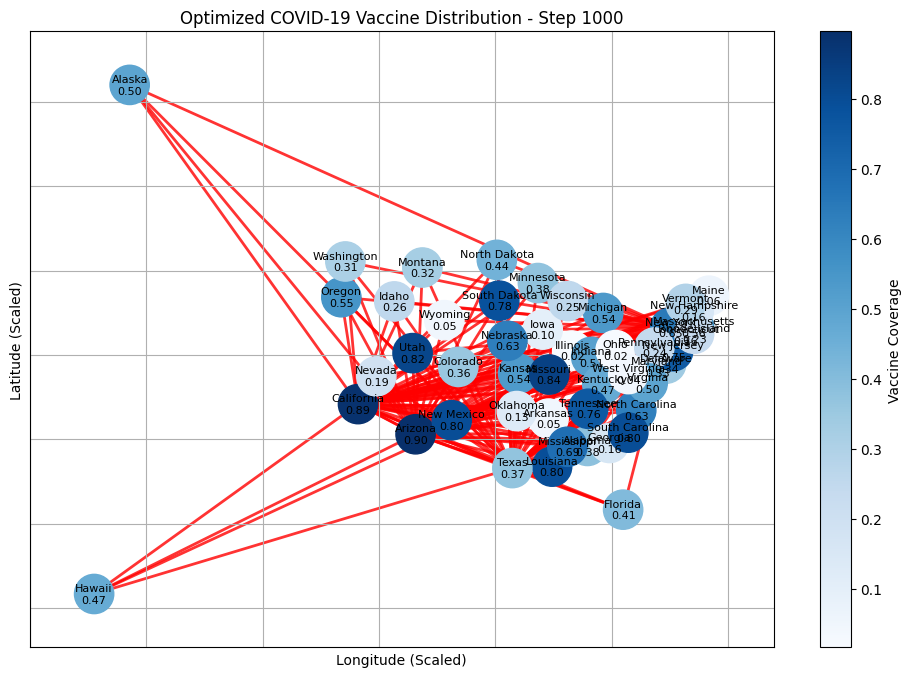

,State,COVID Vaccine Coverage
0,Alabama,0.383746
1,Alaska,0.495038
2,Arizona,0.896253
3,Arkansas,0.048551
4,California,0.887234
5,Colorado,0.357560
6,Connecticut,0.160018
7,Delaware,0.340993
8,Florida,0.408726
9,Georgia,0.163477


In [16]:
# Re-import necessary libraries after execution state reset
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

# Initialize the MultiVaccine Environment
env = MultiVaccineEnv()

# Scale factor for visibility (Alaska & Hawaii fixed)
scale_factor = 3  # Adjust this value to spread states apart
state_coords = {
    state: (lat * scale_factor, lon * scale_factor)  # Scale latitude and longitude
    for state, (lat, lon) in {
        'Alabama': (32.806671, -86.791130), 'Alaska': (61.370716, -152.404419), 'Arizona': (33.729759, -111.431221),
        'Arkansas': (34.969704, -92.373123), 'California': (36.116203, -119.681564), 'Colorado': (39.059811, -105.311104),
        'Connecticut': (41.597782, -72.755371), 'Delaware': (39.318523, -75.507141), 'Florida': (27.766279, -81.686783),
        'Georgia': (33.040619, -83.643074), 'Hawaii': (21.094318, -157.498337), 'Idaho': (44.240459, -114.478828),
        'Illinois': (40.349457, -88.986137), 'Indiana': (39.849426, -86.258278), 'Iowa': (42.011539, -93.210526),
        'Kansas': (38.526600, -96.726486), 'Kentucky': (37.668140, -84.670067), 'Louisiana': (31.169546, -91.867805),
        'Maine': (44.693947, -69.381927), 'Maryland': (39.063946, -76.802101), 'Massachusetts': (42.230171, -71.530106),
        'Michigan': (43.326618, -84.536095), 'Minnesota': (45.694454, -93.900192), 'Mississippi': (32.741646, -89.678696),
        'Missouri': (38.456085, -92.288368), 'Montana': (46.921925, -110.454353), 'Nebraska': (41.125370, -98.268082),
        'Nevada': (38.313515, -117.055374), 'New Hampshire': (43.452492, -71.563896), 'New Jersey': (40.298904, -74.521011),
        'New Mexico': (34.840515, -106.248482), 'New York': (42.165726, -74.948051), 'North Carolina': (35.630066, -79.806419),
        'North Dakota': (47.528912, -99.784012), 'Ohio': (40.388783, -82.764915), 'Oklahoma': (35.565342, -96.928917),
        'Oregon': (44.572021, -122.070938), 'Pennsylvania': (40.590752, -77.209755), 'Rhode Island': (41.680893, -71.511780),
        'South Carolina': (33.856892, -80.945007), 'South Dakota': (44.299782, -99.438828), 'Tennessee': (35.747845, -86.692345),
        'Texas': (31.054487, -97.563461), 'Utah': (40.150032, -111.862434), 'Vermont': (44.045876, -72.710686),
        'Virginia': (37.769337, -78.169968), 'Washington': (47.400902, -121.490494), 'West Virginia': (38.491226, -80.954456),
        'Wisconsin': (44.268543, -89.616508), 'Wyoming': (42.755966, -107.302490)
    }.items()
}

# Create a Fully Connected Graph
G_covid = nx.complete_graph(state_coords.keys())

# Special connections for Alaska and Hawaii (Air & Boat routes)
G_covid.add_edges_from([
    ("Alaska", "Washington"), ("Alaska", "California"),  
    ("Hawaii", "California"), ("Hawaii", "Texas")        
])

# Function to update vaccine coverage dynamically
def update_vaccine_coverage():
    return {state: env.step(random.randint(0, 11))[0][2] for state in G_covid.nodes()}

# Function to compute MST and Dijkstra's paths
def compute_optimized_routes():
    # Compute new weights (inverse vaccine coverage)
    for u, v in G_covid.edges():
        weight = 1 / (0.1 + (state_covid_coverage[u] + state_covid_coverage[v]) / 2)
        G_covid[u][v]['weight'] = weight

    # Compute MST (minimum required routes)
    mst = nx.minimum_spanning_tree(G_covid, weight='weight')

    # Compute Dijkstra's shortest paths from major vaccine hubs
    vaccine_hubs = ["California", "Texas", "New York"]
    optimal_routes = set(mst.edges())
    for hub in vaccine_hubs:
        shortest_paths = nx.single_source_dijkstra_path(G_covid, hub, weight='weight')
        for target in shortest_paths:
            path = shortest_paths[target]
            for i in range(len(path) - 1):
                optimal_routes.add((path[i], path[i+1]))

    return optimal_routes

# Run the simulation until optimal routes remain
best_results = []
max_steps = 1000

for step in range(max_steps):
    # Update vaccine coverage dynamically
    state_covid_coverage = update_vaccine_coverage()

    # Compute optimal routes (MST + Dijkstra)
    optimal_routes = compute_optimized_routes()

    # Store the best 4 intermediate results
    if step in [1, 3, 5, 7] or step == max_steps - 1:
        best_results.append((step, optimal_routes.copy(), state_covid_coverage.copy()))

# Display the best 4 results + final result
for step, optimal_routes, state_covid_coverage in best_results:
    plt.figure(figsize=(12, 8))
    
    # Get positions
    pos = {state: (coords[1], coords[0]) for state, coords in state_coords.items()}

    # Draw the graph
    node_colors = [state_covid_coverage[state] for state in G_covid.nodes()]
    nodes = nx.draw_networkx_nodes(G_covid, pos, node_color=node_colors, cmap="Blues", node_size=800)
    
    # Draw only optimal routes
    nx.draw_networkx_edges(G_covid, pos, edgelist=optimal_routes, edge_color="red", width=2, alpha=0.8)
    
    # Labels with vaccine coverage
    state_labels = {state: f"{state}\n{state_covid_coverage[state]:.2f}" for state in G_covid.nodes()}
    nx.draw_networkx_labels(G_covid, pos, labels=state_labels, font_size=8, font_color="black")

    # Color bar
    cbar = plt.colorbar(nodes)
    cbar.set_label("Vaccine Coverage")

    plt.title(f"Optimized COVID-19 Vaccine Distribution - Step {step + 1}")
    plt.xlabel("Longitude (Scaled)")
    plt.ylabel("Latitude (Scaled)")
    plt.grid(True)
    plt.show()

    # Display Coverage Table
    df_covid = pd.DataFrame(state_covid_coverage.items(), columns=["State", "COVID Vaccine Coverage"])
    display(df_covid)


Optimized Flu Vaccine Distribution Across U.S. States Using Network Routing:

This cell simulates national-level flu vaccine distribution and coverage dynamics using a fully connected graph of U.S. states. The network graph updates based on flu vaccine coverage levels, and uses minimum spanning trees (MSTs) and Dijkstra's algorithm to identify the most efficient distribution routes over time.

🧩 What It Models:
Nodes: U.S. states, each assigned a simulated flu vaccine coverage value.

Edges: Represent potential distribution routes between states.

Special Links: Direct connections are added for Alaska and Hawaii to mainland hubs.



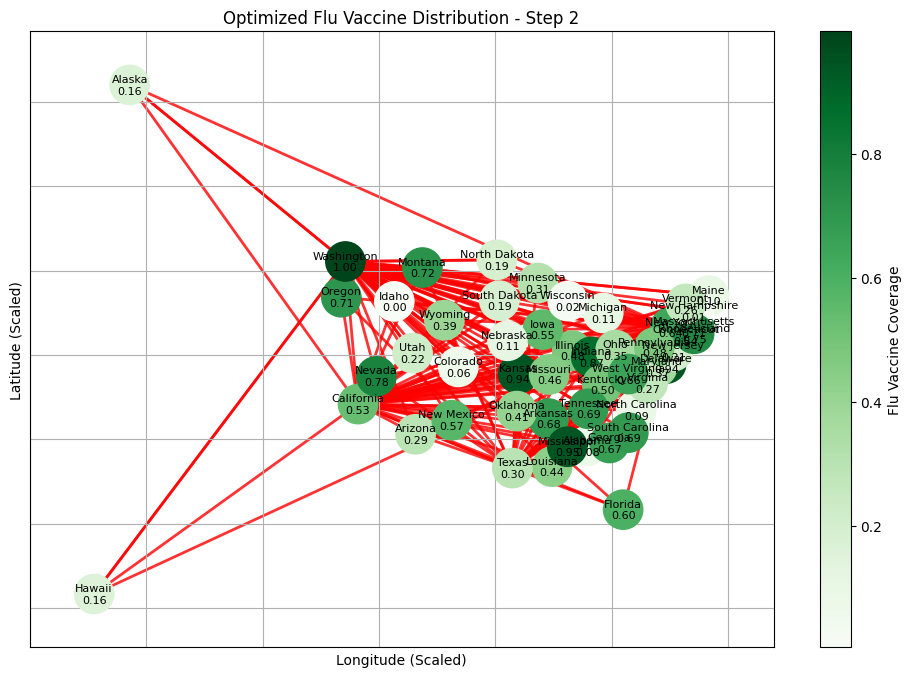

,State,Flu Vaccine Coverage
0,Alabama,0.077645
1,Alaska,0.163693
2,Arizona,0.292890
3,Arkansas,0.684196
4,California,0.528606
5,Colorado,0.063220
6,Connecticut,0.537321
7,Delaware,0.944327
8,Florida,0.600388
9,Georgia,0.670219


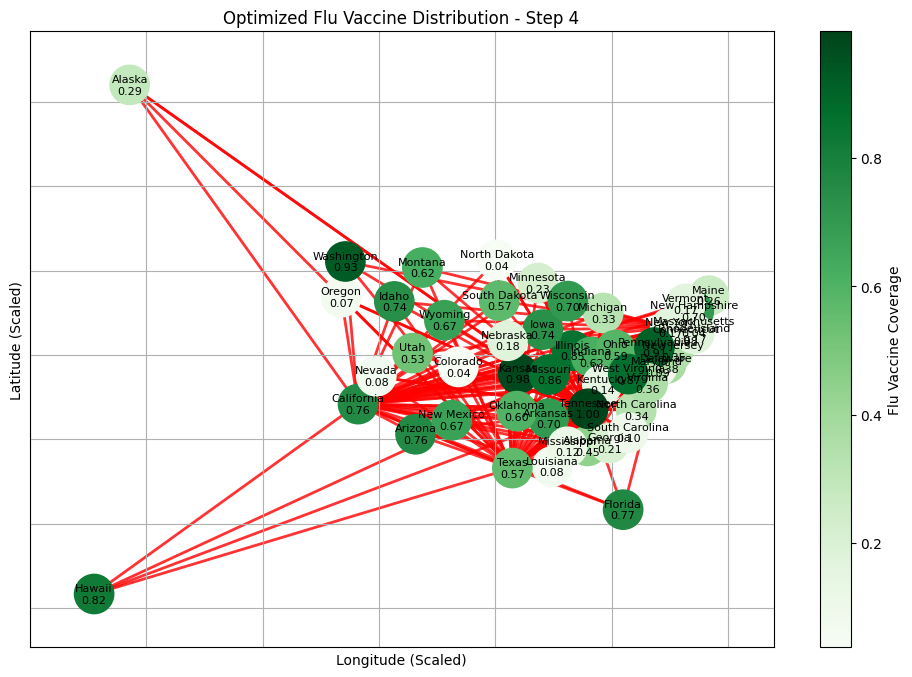

,State,Flu Vaccine Coverage
0,Alabama,0.445319
1,Alaska,0.286702
2,Arizona,0.760348
3,Arkansas,0.699823
4,California,0.757879
5,Colorado,0.036948
6,Connecticut,0.077725
7,Delaware,0.378151
8,Florida,0.768225
9,Georgia,0.207526


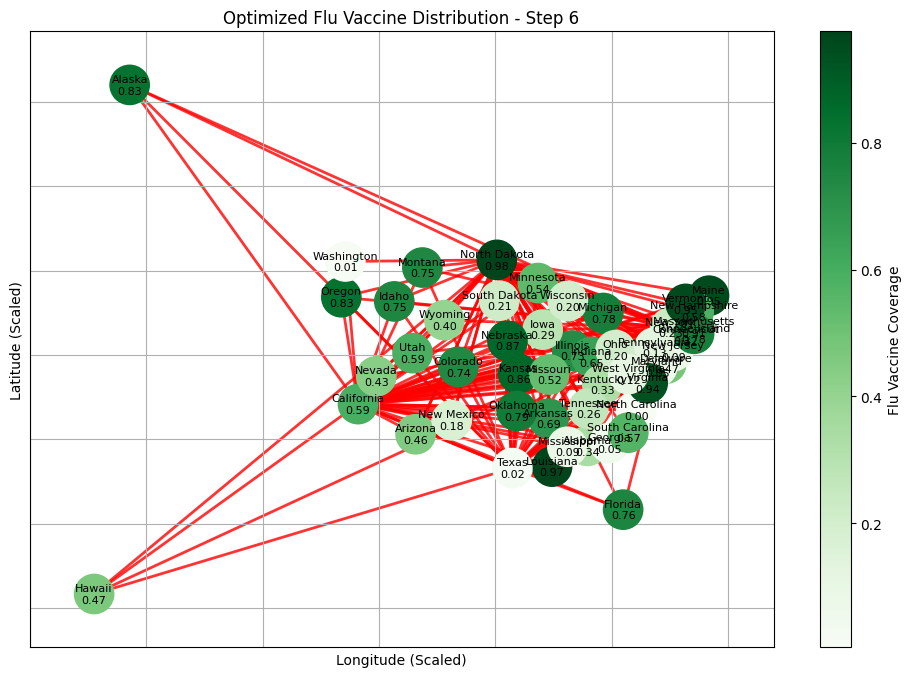

,State,Flu Vaccine Coverage
0,Alabama,0.340668
1,Alaska,0.830968
2,Arizona,0.455277
3,Arkansas,0.693830
4,California,0.594781
5,Colorado,0.738790
6,Connecticut,0.321918
7,Delaware,0.474899
8,Florida,0.757515
9,Georgia,0.047326


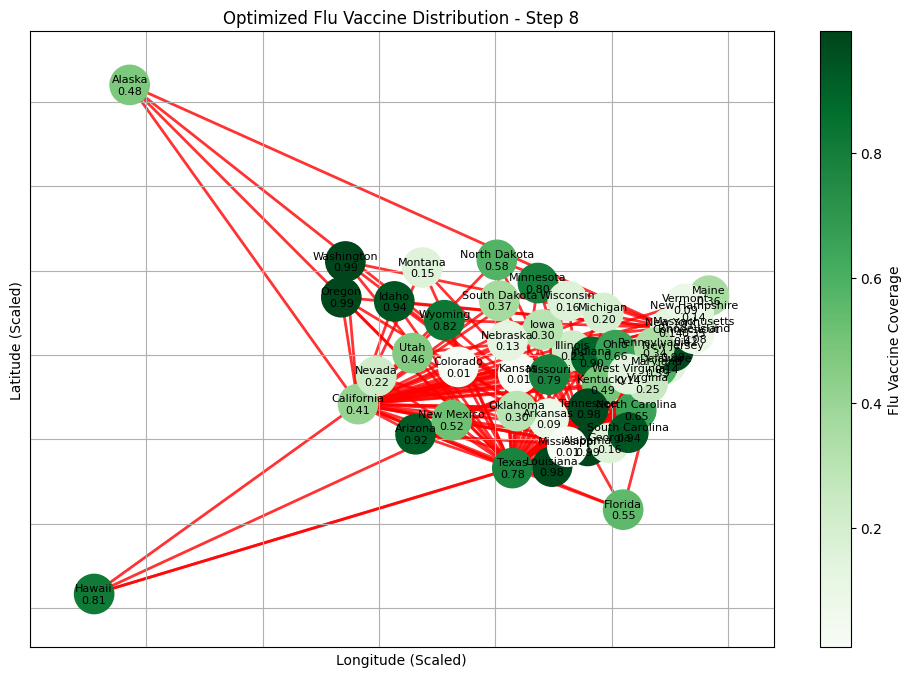

,State,Flu Vaccine Coverage
0,Alabama,0.994292
1,Alaska,0.480881
2,Arizona,0.923589
3,Arkansas,0.094815
4,California,0.405036
5,Colorado,0.012169
6,Connecticut,0.418532
7,Delaware,0.141463
8,Florida,0.552315
9,Georgia,0.160587


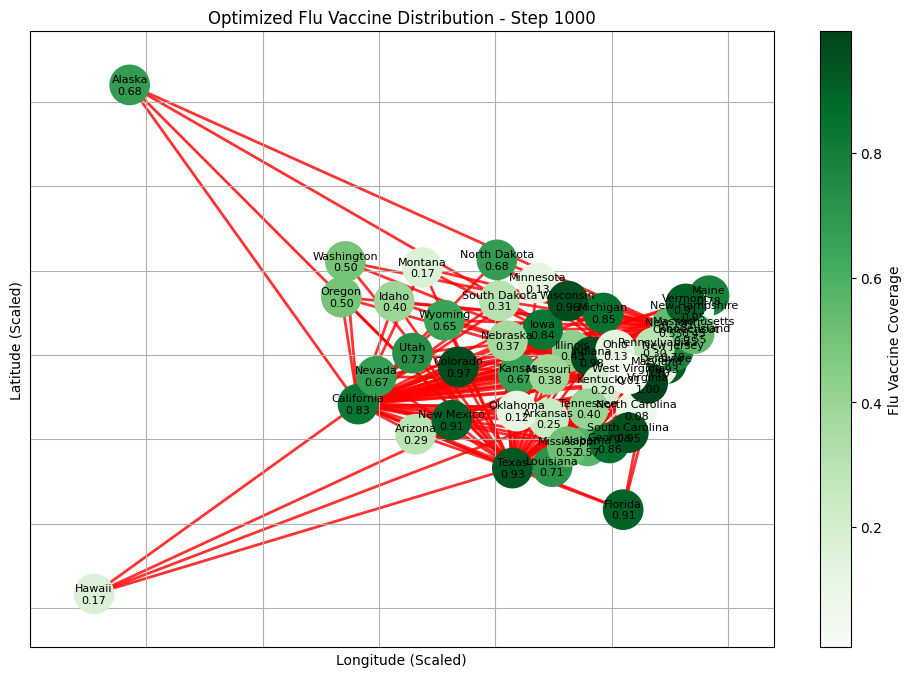

,State,Flu Vaccine Coverage
0,Alabama,0.573941
1,Alaska,0.680803
2,Arizona,0.294599
3,Arkansas,0.246242
4,California,0.828899
5,Colorado,0.969166
6,Connecticut,0.250733
7,Delaware,0.930202
8,Florida,0.905422
9,Georgia,0.861481


In [17]:
# Initialize the MultiVaccine Environment
env = MultiVaccineEnv()

# Scale factor for visibility (Alaska & Hawaii fixed)
scale_factor = 3  # Adjust this value to spread states apart
state_coords = {
    state: (lat * scale_factor, lon * scale_factor)  # Scale latitude and longitude
    for state, (lat, lon) in {
        'Alabama': (32.806671, -86.791130), 'Alaska': (61.370716, -152.404419), 'Arizona': (33.729759, -111.431221),
        'Arkansas': (34.969704, -92.373123), 'California': (36.116203, -119.681564), 'Colorado': (39.059811, -105.311104),
        'Connecticut': (41.597782, -72.755371), 'Delaware': (39.318523, -75.507141), 'Florida': (27.766279, -81.686783),
        'Georgia': (33.040619, -83.643074), 'Hawaii': (21.094318, -157.498337), 'Idaho': (44.240459, -114.478828),
        'Illinois': (40.349457, -88.986137), 'Indiana': (39.849426, -86.258278), 'Iowa': (42.011539, -93.210526),
        'Kansas': (38.526600, -96.726486), 'Kentucky': (37.668140, -84.670067), 'Louisiana': (31.169546, -91.867805),
        'Maine': (44.693947, -69.381927), 'Maryland': (39.063946, -76.802101), 'Massachusetts': (42.230171, -71.530106),
        'Michigan': (43.326618, -84.536095), 'Minnesota': (45.694454, -93.900192), 'Mississippi': (32.741646, -89.678696),
        'Missouri': (38.456085, -92.288368), 'Montana': (46.921925, -110.454353), 'Nebraska': (41.125370, -98.268082),
        'Nevada': (38.313515, -117.055374), 'New Hampshire': (43.452492, -71.563896), 'New Jersey': (40.298904, -74.521011),
        'New Mexico': (34.840515, -106.248482), 'New York': (42.165726, -74.948051), 'North Carolina': (35.630066, -79.806419),
        'North Dakota': (47.528912, -99.784012), 'Ohio': (40.388783, -82.764915), 'Oklahoma': (35.565342, -96.928917),
        'Oregon': (44.572021, -122.070938), 'Pennsylvania': (40.590752, -77.209755), 'Rhode Island': (41.680893, -71.511780),
        'South Carolina': (33.856892, -80.945007), 'South Dakota': (44.299782, -99.438828), 'Tennessee': (35.747845, -86.692345),
        'Texas': (31.054487, -97.563461), 'Utah': (40.150032, -111.862434), 'Vermont': (44.045876, -72.710686),
        'Virginia': (37.769337, -78.169968), 'Washington': (47.400902, -121.490494), 'West Virginia': (38.491226, -80.954456),
        'Wisconsin': (44.268543, -89.616508), 'Wyoming': (42.755966, -107.302490)
    }.items()
}

# Create a Fully Connected Graph for Flu Vaccine
G_flu = nx.complete_graph(state_coords.keys())

# Special connections for Alaska and Hawaii (Air & Boat routes)
G_flu.add_edges_from([
    ("Alaska", "Washington"), ("Alaska", "California"),  
    ("Hawaii", "California"), ("Hawaii", "Texas")        
])

# Function to update flu vaccine coverage dynamically
def update_vaccine_coverage():
    return {state: env.step(random.randint(0, 11))[0][5] for state in G_flu.nodes()}  # Flu vaccine index

# Function to compute MST and Dijkstra's paths
def compute_optimized_routes():
    for u, v in G_flu.edges():
        weight = 1 / (0.1 + (state_flu_coverage[u] + state_flu_coverage[v]) / 2)
        G_flu[u][v]['weight'] = weight

    # Compute MST (minimum required routes)
    mst = nx.minimum_spanning_tree(G_flu, weight='weight')
    
    # Compute Dijkstra's shortest paths from major vaccine hubs
    vaccine_hubs = ["California", "Texas", "New York"]
    optimal_routes = set(mst.edges())
    for hub in vaccine_hubs:
        shortest_paths = nx.single_source_dijkstra_path(G_flu, hub, weight='weight')
        for target in shortest_paths:
            path = shortest_paths[target]
            for i in range(len(path) - 1):
                optimal_routes.add((path[i], path[i+1]))
    
    return optimal_routes

# Run the simulation until optimal routes remain
best_results = []
max_steps = 1000

for step in range(max_steps):
    state_flu_coverage = update_vaccine_coverage()
    optimal_routes = compute_optimized_routes()
    
    if step in [1, 3, 5, 7] or step == max_steps - 1:
        best_results.append((step, optimal_routes.copy(), state_flu_coverage.copy()))

# Display the best 4 results + final result
for step, optimal_routes, state_flu_coverage in best_results:
    plt.figure(figsize=(12, 8))
    
    pos = {state: (coords[1], coords[0]) for state, coords in state_coords.items()}
    node_colors = [state_flu_coverage[state] for state in G_flu.nodes()]
    nodes = nx.draw_networkx_nodes(G_flu, pos, node_color=node_colors, cmap="Greens", node_size=800)
    
    nx.draw_networkx_edges(G_flu, pos, edgelist=optimal_routes, edge_color="red", width=2, alpha=0.8)
    
    state_labels = {state: f"{state}\n{state_flu_coverage[state]:.2f}" for state in G_flu.nodes()}
    nx.draw_networkx_labels(G_flu, pos, labels=state_labels, font_size=8, font_color="black")
    
    cbar = plt.colorbar(nodes)
    cbar.set_label("Flu Vaccine Coverage")
    plt.title(f"Optimized Flu Vaccine Distribution - Step {step + 1}")
    plt.xlabel("Longitude (Scaled)")
    plt.ylabel("Latitude (Scaled)")
    plt.grid(True)
    plt.show()
    
    df_flu = pd.DataFrame(state_flu_coverage.items(), columns=["State", "Flu Vaccine Coverage"])
    display(df_flu)
